In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
FILE_PATH = '/content/drive/My Drive/train.csv'


In [5]:
# load data
CHUNK_SIZE = 200_000
SAMPLE_RATE = 0.10
chunks = []
for chunk in pd.read_csv(FILE_PATH, chunksize=CHUNK_SIZE, low_memory=False):
    sampled = chunk.sample(frac=SAMPLE_RATE, random_state=42)
    chunks.append(sampled)

df_raw = pd.concat(chunks, ignore_index=True)

In [6]:
# đổi tên column
df = df_raw.rename(columns={

    # Customer information
    'fecha_dato': 'date',
    'ncodpers': 'customer_id',
    'ind_empleado': 'employee_index',
    'pais_residencia': 'country',
    'sexo': 'gender',
    'age': 'age',
    'fecha_alta': 'join_date',
    'ind_nuevo': 'new_customer',
    'antiguedad': 'seniority',
    'indrel': 'customer_type',
    'ult_fec_cli_1t': 'last_primary_date',
    'indrel_1mes': 'customer_relation_month_start',
    'tiprel_1mes': 'relation_type',
    'indresi': 'resident',
    'indext': 'foreigner',
    'conyuemp': 'employee_spouse',
    'canal_entrada': 'join_channel',
    'indfall': 'deceased',
    'tipodom': 'address_type',
    'cod_prov': 'province_code',
    'nomprov': 'province',
    'ind_actividad_cliente': 'active_customer',
    'renta': 'income',
    'segmento': 'segment',

    # Product columns
    'ind_ahor_fin_ult1': 'product_savings_account',
    'ind_aval_fin_ult1': 'product_guarantees',
    'ind_cco_fin_ult1': 'product_current_account',
    'ind_cder_fin_ult1': 'product_derivada_account',
    'ind_cno_fin_ult1': 'product_payroll_account',
    'ind_ctju_fin_ult1': 'product_junior_account',
    'ind_ctma_fin_ult1': 'product_mas_particular_account',
    'ind_ctop_fin_ult1': 'product_particular_account',
    'ind_ctpp_fin_ult1': 'product_particular_plus_account',
    'ind_deco_fin_ult1': 'product_short_term_deposit',
    'ind_deme_fin_ult1': 'product_medium_term_deposit',
    'ind_dela_fin_ult1': 'product_long_term_deposit',
    'ind_ecue_fin_ult1': 'product_e_account',
    'ind_fond_fin_ult1': 'product_funds',
    'ind_hip_fin_ult1': 'product_mortgage',
    'ind_plan_fin_ult1': 'product_pension_plan',
    'ind_pres_fin_ult1': 'product_loans',
    'ind_reca_fin_ult1': 'product_taxes',
    'ind_tjcr_fin_ult1': 'product_credit_card',
    'ind_valo_fin_ult1': 'product_securities',
    'ind_viv_fin_ult1': 'product_home_account',
    'ind_nomina_ult1': 'product_payroll',
    'ind_nom_pens_ult1': 'product_pension',
    'ind_recibo_ult1': 'product_direct_debit'
})

In [7]:
product_cols = [c for c in df.columns if c.startswith('product_')]
df[product_cols] = df[product_cols].apply(pd.to_numeric, errors='coerce').fillna(0).astype('int8')
df['age']        = pd.to_numeric(df['age'], errors='coerce').astype('float32')
df['income']     = pd.to_numeric(df['income'], errors='coerce').astype('float32')
df['date']       = pd.to_datetime(df['date'])
df['join_date']  = pd.to_datetime(df['join_date'])

In [8]:
print(df.shape)
df.head()

(1271586, 48)


,date,customer_id,employee_index,country,gender,age,join_date,new_customer,seniority,customer_type,...,product_mortgage,product_pension_plan,product_loans,product_taxes,product_credit_card,product_securities,product_home_account,product_payroll,product_pension,product_direct_debit
0,2015-01-28,992094,N,ES,V,45.0,2011-12-09,0.0,43,1.0,...,0,0,0,0,0,0,0,0,0,0
1,2015-01-28,1093982,N,ES,V,26.0,2012-11-02,0.0,32,1.0,...,0,0,0,0,0,0,0,0,0,0
2,2015-01-28,1291657,N,ES,V,21.0,2014-08-04,0.0,12,1.0,...,0,0,0,0,0,0,0,0,0,0
3,2015-01-28,1070924,N,ES,H,23.0,2012-10-01,0.0,33,1.0,...,0,0,0,0,0,0,0,0,0,0
4,2015-01-28,1038651,N,ES,V,23.0,2012-08-01,0.0,35,1.0,...,0,0,0,0,0,0,0,0,0,0


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1271586 entries, 0 to 1271585
Data columns (total 48 columns):
 #   Column                           Non-Null Count    Dtype         
---  ------                           --------------    -----         
 0   date                             1271586 non-null  datetime64[ns]
 1   customer_id                      1271586 non-null  int64         
 2   employee_index                   1268792 non-null  object        
 3   country                          1268792 non-null  object        
 4   gender                           1268788 non-null  object        
 5   age                              1268792 non-null  float32       
 6   join_date                        1268792 non-null  datetime64[ns]
 7   new_customer                     1268792 non-null  float64       
 8   seniority                        1271586 non-null  object        
 9   customer_type                    1268792 non-null  float64       
 10  last_primary_date             

- Vì không load được full dataset thế nên t sẽ chỉ lấy 10%
- Đổi tên column sang tiếng anh cho dễ hiểu
- thay vài datatype cho tối ưu ram

# Data Cleaning

In [10]:
# missing Value
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_report = pd.DataFrame({
    'missing_count': missing,
    'missing_pct': missing_pct
}).query('missing_count > 0').sort_values('missing_pct', ascending=False)
print(missing_report)

                               missing_count  missing_pct
employee_spouse                      1271432        99.99
last_primary_date                    1269311        99.82
income                                255875        20.12
segment                                17979         1.41
join_channel                           17690         1.39
customer_relation_month_start          14450         1.14
relation_type                          14450         1.14
province                                8996         0.71
province_code                           8996         0.71
employee_index                          2794         0.22
age                                     2794         0.22
gender                                  2798         0.22
country                                 2794         0.22
join_date                               2794         0.22
resident                                2794         0.22
customer_type                           2794         0.22
new_customer  

In [11]:
# invalid value
df['seniority'] = pd.to_numeric(df['seniority'], errors='coerce')
df['seniority'] = df['seniority'].clip(lower=0).astype('float32')
invalid_age = df[(df['age'] < 18) | (df['age'] > 100)]
print(f"Invalid age (<18 hoặc >100): {len(invalid_age)}")
df['age'] = df['age'].clip(lower=18, upper=100)

Invalid age (<18 hoặc >100): 12440


In [12]:
# fix datatype
df['date']      = pd.to_datetime(df['date'])
df['join_date'] = pd.to_datetime(df['join_date'])
df['age']      = df['age'].astype('float32')
df['income']   = pd.to_numeric(df['income'], errors='coerce').astype('float32')
df['seniority']= pd.to_numeric(df['seniority'], errors='coerce').astype('float32')
df['gender'] = df['gender'].astype(str).str.strip().replace('nan', np.nan)
df['gender'] = df['gender'].where(df['gender'].isin(['H', 'V']), np.nan)
product_cols = [c for c in df.columns if c.startswith('product_')]
df[product_cols] = (df[product_cols]
                    .apply(pd.to_numeric, errors='coerce')
                    .fillna(0)
                    .astype('int8'))

cat_cols = ['gender', 'segment', 'relation_type', 'employee_index', 'country']
for col in cat_cols:
    df[col] = df[col].astype('category')

In [13]:
# check duplicates
dup_customer_month = df.duplicated(subset=['customer_id', 'date']).sum()
dup_rows = df.duplicated().sum()
if dup_customer_month > 0:
    df = df.drop_duplicates(subset=['customer_id', 'date'], keep='last')
else:
    print("0 duplicate")

0 duplicate


In [14]:
# drop employee_spouse column
df_clean = df.drop(columns=['employee_spouse'])

Missing Value
- Unique customer: 695,171
- Cột employee_spouse thiếu 99.99% nên cho nhót
- Cột income (renta) thiếu 20.12% có thể dùng median/mode...
- Nhiều cột thiếu đúng 2794 dòng có thể là nhóm khách hàng chưa cập nhật thông tin

Invalid Value
- Tuổi [2-163] sửa thành [18-100]

**Insight:**
- Phân khúc (segmento):
  + 02 (Cá nhân): 58.3%
  + 03 (Grraduate): 36.1%
  + 01 (VIP): 4.1%
  + NaN: 1.4%
- Country: 98.8% là Tây Ban Nha
- Không phát hiện duplicate row

# EDA

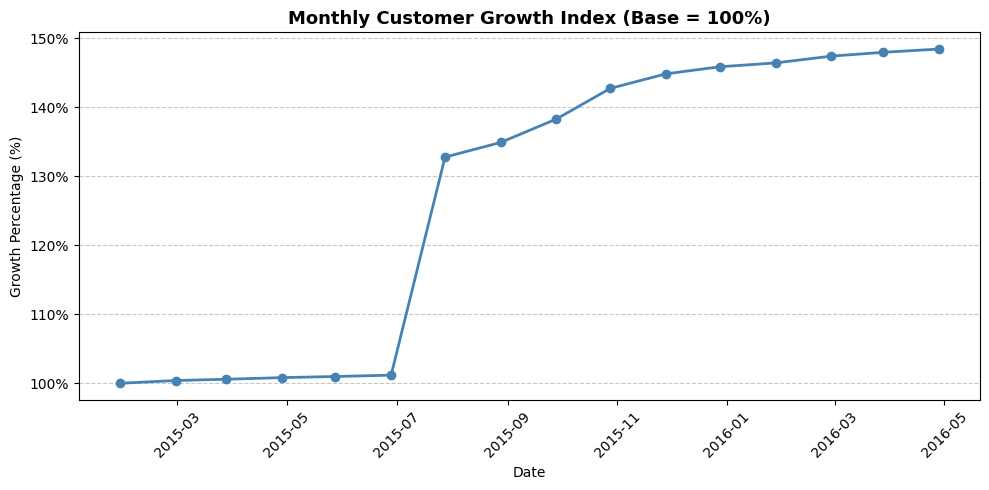

In [15]:
# total customers
customers_per_month = (df_clean.groupby('date')['customer_id']
                       .nunique().reset_index()
                       .rename(columns={'customer_id': 'n_customers'}))
plt.figure(figsize=(10, 5))
first_month_val = customers_per_month['n_customers'].iloc[0]
customers_per_month['growth_pct'] = (customers_per_month['n_customers'] / first_month_val) * 100
plt.plot(customers_per_month['date'], customers_per_month['growth_pct'],
         marker='o', color='steelblue', linewidth=2, label='Growth Index')
plt.title('Monthly Customer Growth Index (Base = 100%)', fontsize=13, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Growth Percentage (%)')
plt.xticks(rotation=45)
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x)}%'))
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

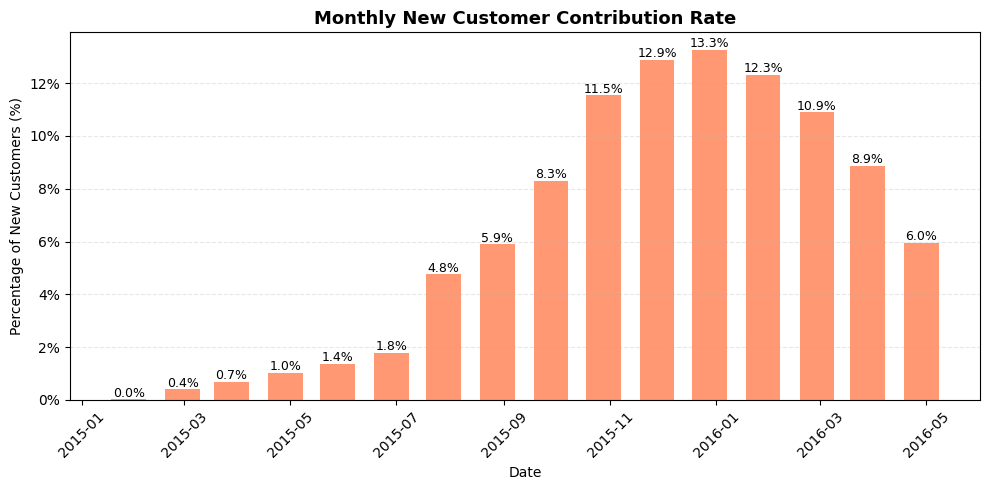

In [16]:
# new customers
new_per_month = (df_clean[df_clean['new_customer'] == 1]
                 .groupby('date')['customer_id']
                 .nunique().reset_index()
                 .rename(columns={'customer_id': 'n_new'}))
plt.figure(figsize=(10, 5))
total_new_all_time = new_per_month['n_new'].sum()
new_per_month['new_pct'] = (new_per_month['n_new'] / total_new_all_time) * 100
plt.bar(new_per_month['date'], new_per_month['new_pct'],
        color='coral', alpha=0.8, width=20, label='% of Total New Assets')
plt.title('Monthly New Customer Contribution Rate', fontsize=13, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Percentage of New Customers (%)')
plt.xticks(rotation=45)
for i, val in enumerate(new_per_month['new_pct']):
    plt.text(new_per_month['date'].iloc[i], val + 0.1, f'{val:.1f}%',
             ha='center', fontsize=9)
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x)}%'))
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

- tăng trưởng 31.24% từ 6/15 đến 7/15
- Số lượng khách hàng mới đạt đỉnh vào giai đoạn cuối-đầu năm (11/15-2/16) và giảm sâu từ giữa năm (3/16-5-16)

-> Có tính mùa vụ

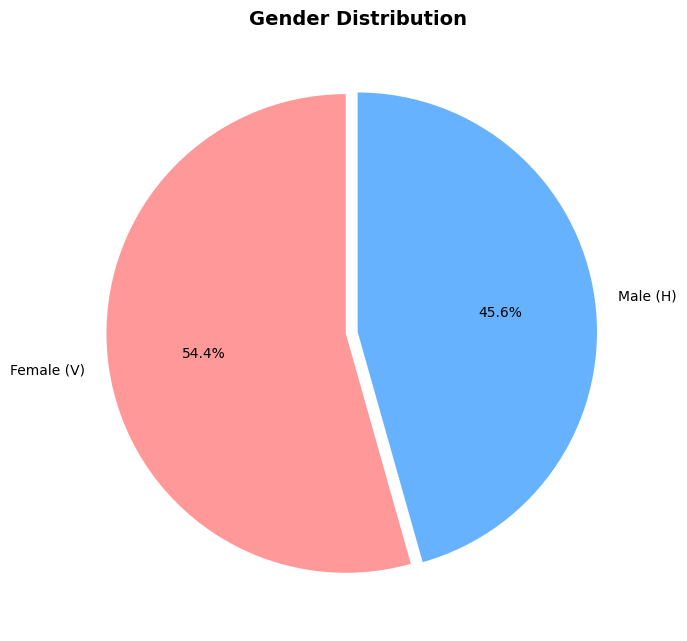

In [17]:
# gender distribution
latest = (df_clean.sort_values('date')
          .groupby('customer_id').last().reset_index())
plt.figure(figsize=(7, 7))
gender_data = latest['gender'].value_counts(dropna=True)
plt.pie(gender_data.values,
        labels=['Female (V)', 'Male (H)'],
        autopct='%1.1f%%',
        colors=['#FF9999', '#66B2FF'],
        startangle=90,
        explode=(0.05, 0))
plt.title('Gender Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

phân bố khá đồng đều giữa nam và nữ


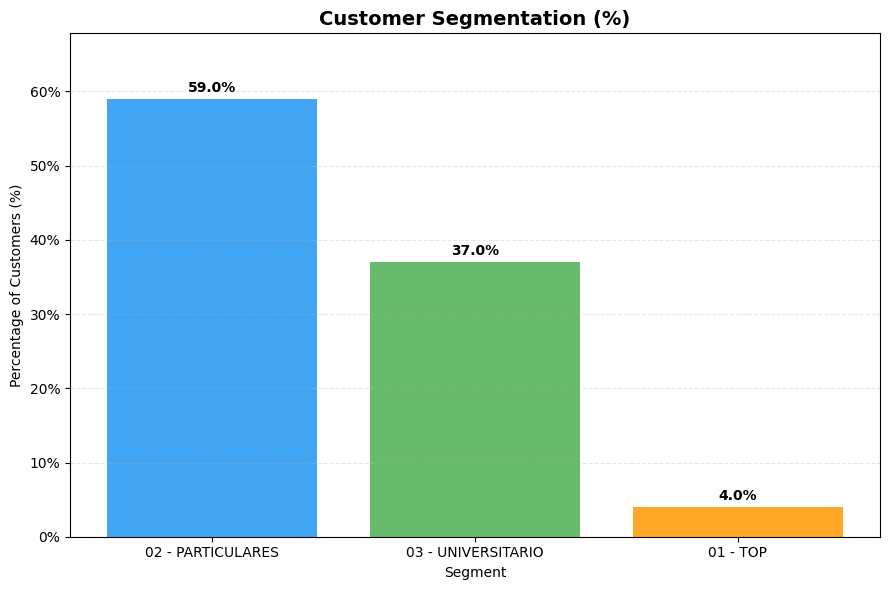

In [18]:
# customer segmentation
plt.figure(figsize=(9, 6))
seg_perc = latest['segment'].value_counts(normalize=True).dropna() * 100
bars = plt.bar(seg_perc.index, seg_perc.values,
               color=['#2196F3', '#4CAF50', '#FF9800'], alpha=0.85)
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.5,
             f'{yval:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')
plt.title('Customer Segmentation (%)', fontsize=14, fontweight='bold')
plt.xlabel('Segment')
plt.ylabel('Percentage of Customers (%)')
plt.ylim(0, max(seg_perc.values) * 1.15)
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x)}%'))
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

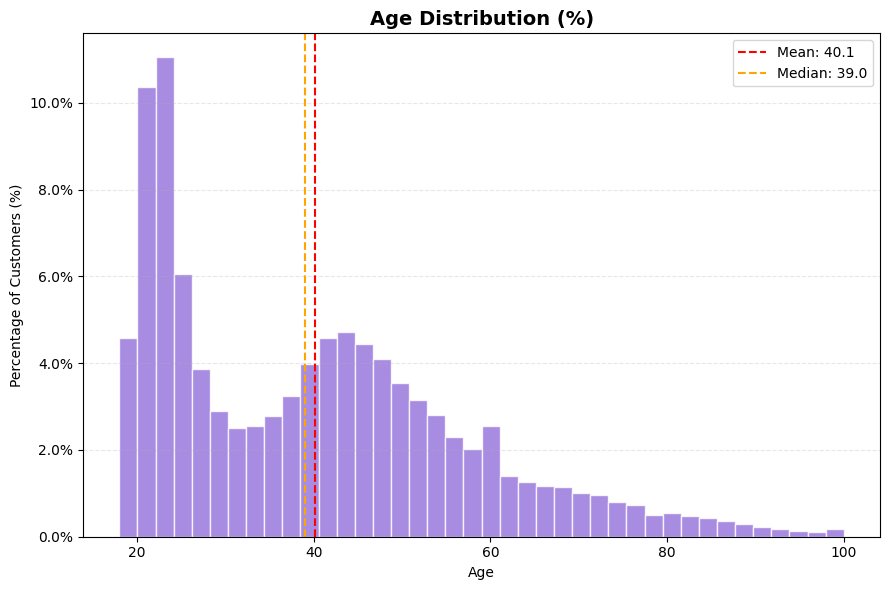

In [19]:
# age distribution
plt.figure(figsize=(9, 6))
age_data = latest['age'].dropna()
age_data = age_data[(age_data >= 18) & (age_data <= 100)]
weights = np.ones_like(age_data) / len(age_data) * 100
plt.hist(age_data, bins=40, weights=weights, color='mediumpurple', alpha=0.8, edgecolor='white')
plt.axvline(age_data.mean(), color='red', linestyle='--',
            label=f'Mean: {age_data.mean():.1f}')
plt.axvline(age_data.median(), color='orange', linestyle='--',
            label=f'Median: {age_data.median():.1f}')
plt.title('Age Distribution (%)', fontsize=14, fontweight='bold')
plt.xlabel('Age')
plt.ylabel('Percentage of Customers (%)')
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.1f}%'))
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

Độ tuổi tbinh là 40.2 và trung vị là 39 nhưng nhiều nhất là nhóm sinh viên hoặc người mới đi làm (20-25t), đây là nhóm khách hàng tiềm năng của ngân hàng


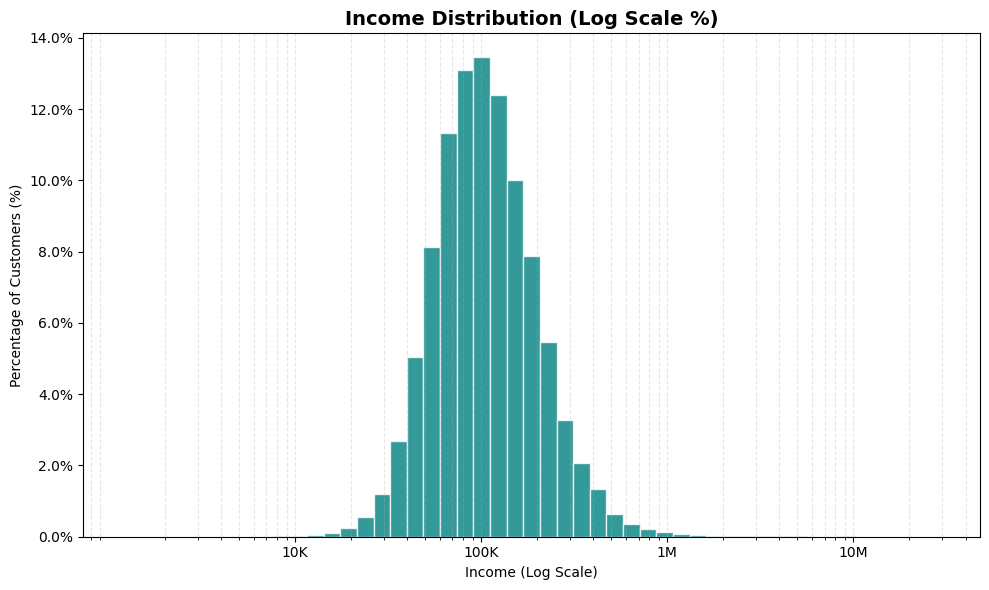

In [20]:
# income distribution
plt.figure(figsize=(10, 6))
income_data = latest[latest['income'] > 0]['income'].dropna()
weights_inc = np.ones_like(income_data) / len(income_data) * 100
bins = np.logspace(np.log10(income_data.min()), np.log10(income_data.max()), 50)
plt.hist(income_data, bins=bins, weights=weights_inc, color='teal', alpha=0.8, edgecolor='white')
plt.xscale('log')
plt.title('Income Distribution (Log Scale %)', fontsize=14, fontweight='bold')
plt.xlabel('Income (Log Scale)')
plt.ylabel('Percentage of Customers (%)')
plt.xticks([10**4, 10**5, 10**6, 10**7], ['10K', '100K', '1M', '10M'])
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.1f}%'))
plt.grid(axis='x', which='both', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

phân phối chuẩn

<Figure size 1000x600 with 0 Axes>

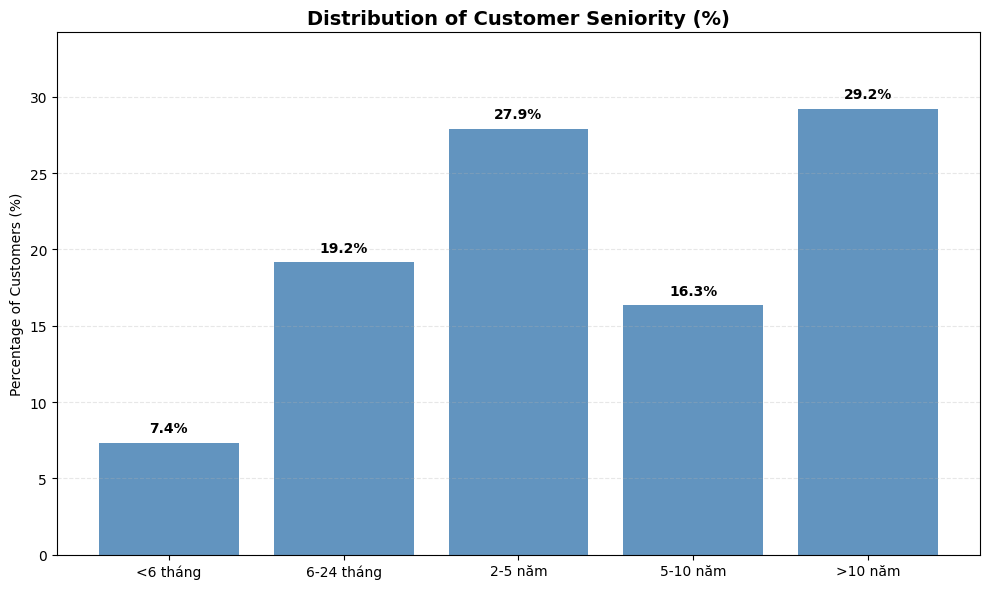

In [21]:
# customer seniority distribution
bins   = [0, 6, 24, 60, 120, 999]
labels = ['<6 tháng', '6-24 tháng', '2-5 năm', '5-10 năm', '>10 năm']
latest['seniority_group'] = pd.cut(latest['seniority'],
                                    bins=bins, labels=labels)
plt.figure(figsize=(10, 6))
sen_perc = latest['seniority_group'].value_counts(normalize=True).sort_index() * 100
plt.figure(figsize=(10, 6))
sen_perc = latest['seniority_group'].value_counts(normalize=True).sort_index() * 100
bars = plt.bar(sen_perc.index, sen_perc.values, color='steelblue', alpha=0.85)
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.5,
             f'{height:.1f}%', ha='center', va='bottom', fontweight='bold')
plt.title('Distribution of Customer Seniority (%)', fontsize=14, fontweight='bold')
plt.ylabel('Percentage of Customers (%)')
plt.ylim(0, max(sen_perc.values) + 5)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

- Tệp khách hàng kì cựu (>10n) chiếm ưu thế với 29.2%
- Gần 50% khách hàng có thâm niên trên 5 năm cho thấy ngân hàng có khả năng giữ chân tốt.

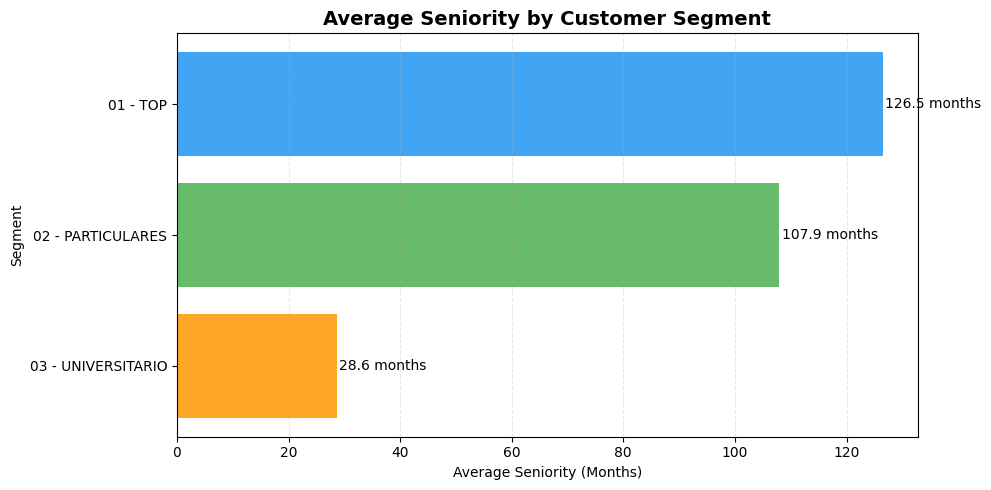

In [22]:
# average seniority by customer
plt.figure(figsize=(10, 5))
sen_seg = (latest.groupby('segment', observed=True)['seniority']
           .mean().sort_values(ascending=True))
plt.barh(sen_seg.index, sen_seg.values,
         color=['#FF9800', '#4CAF50', '#2196F3'], alpha=0.85)
for i, val in enumerate(sen_seg.values):
    plt.text(val + 0.5, i, f'{val:.1f} months', va='center', fontsize=10)
plt.title('Average Seniority by Customer Segment', fontsize=14, fontweight='bold')
plt.xlabel('Average Seniority (Months)')
plt.ylabel('Segment')
plt.grid(axis='x', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

# PRODUCT ANALYSIS

In [23]:
# nhóm column các product
product_cols = [c for c in df_clean.columns if c.startswith('product_')]
product_names = {
    'product_savings_account':        'Savings Account',
    'product_guarantees':             'Guarantees',
    'product_current_account':        'Current Account',
    'product_derivada_account':       'Derivada Account',
    'product_payroll_account':        'Payroll Account',
    'product_junior_account':         'Junior Account',
    'product_mas_particular_account': 'Mas Particular',
    'product_particular_account':     'Particular Account',
    'product_particular_plus_account':'Particular Plus',
    'product_short_term_deposit':     'Short-term Deposit',
    'product_medium_term_deposit':    'Medium-term Deposit',
    'product_long_term_deposit':      'Long-term Deposit',
    'product_e_account':              'E-account',
    'product_funds':                  'Funds',
    'product_mortgage':               'Mortgage',
    'product_pension_plan':           'Pension Plan',
    'product_loans':                  'Loans',
    'product_taxes':                  'Taxes',
    'product_credit_card':            'Credit Card',
    'product_securities':             'Securities',
    'product_home_account':           'Home Account',
    'product_payroll':                'Payroll',
    'product_pension':                'Pension',
    'product_direct_debit':           'Direct Debit'
}

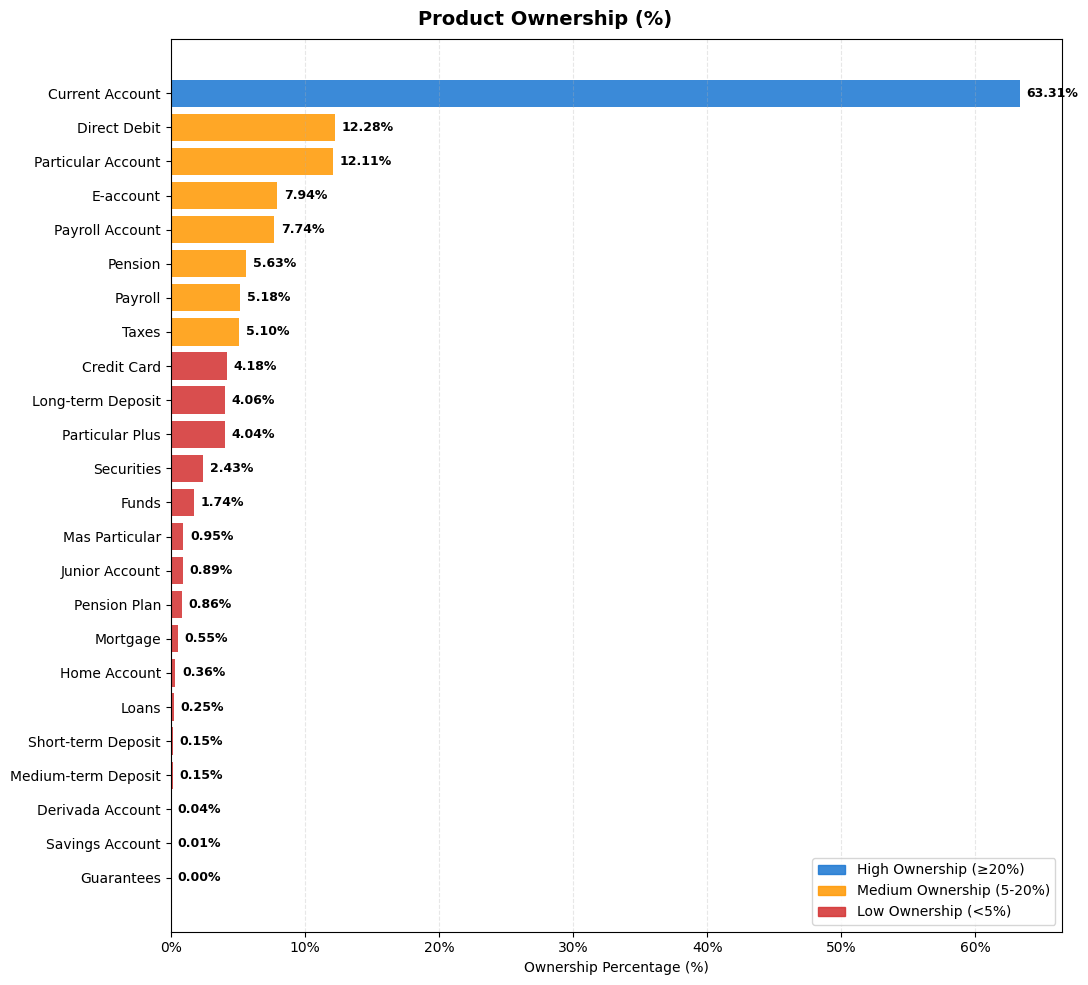

In [24]:
# product ownership & data imbalance
latest = (df_clean.sort_values('date')
          .groupby('customer_id').last().reset_index())
ownership_pct = (latest[product_cols].mean() * 100).rename(product_names).sort_values(ascending=True)
fig, ax = plt.subplots(figsize=(11, 10))
fig.suptitle('Product Ownership (%)', fontsize=14, fontweight='bold')
colors = ['#d32f2f' if v < 5 else '#FF9800' if v < 20 else '#1976D2'
          for v in ownership_pct.values]

bars = ax.barh(ownership_pct.index, ownership_pct.values, color=colors, alpha=0.85)
for bar, val in zip(bars, ownership_pct.values):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val:.2f}%', va='center', fontsize=9, fontweight='bold')

ax.set_xlabel('Ownership Percentage (%)')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x)}%'))
ax.legend(handles=[
    plt.Rectangle((0,0),1,1, color='#1976D2', alpha=0.85, label='High Ownership (≥20%)'),
    plt.Rectangle((0,0),1,1, color='#FF9800', alpha=0.85, label='Medium Ownership (5-20%)'),
    plt.Rectangle((0,0),1,1, color='#d32f2f', alpha=0.85, label='Low Ownership (<5%)')
], loc='lower right', fontsize=10)
plt.grid(axis='x', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.savefig('product_analysis_combined.png', dpi=150, bbox_inches='tight')
plt.show()

Current Account chiếm đến 63.31% trong khi Saving Account hay Guarantees gần như 0%

-> Có sự chênh lệch lớn

-> Model dễ bị bias

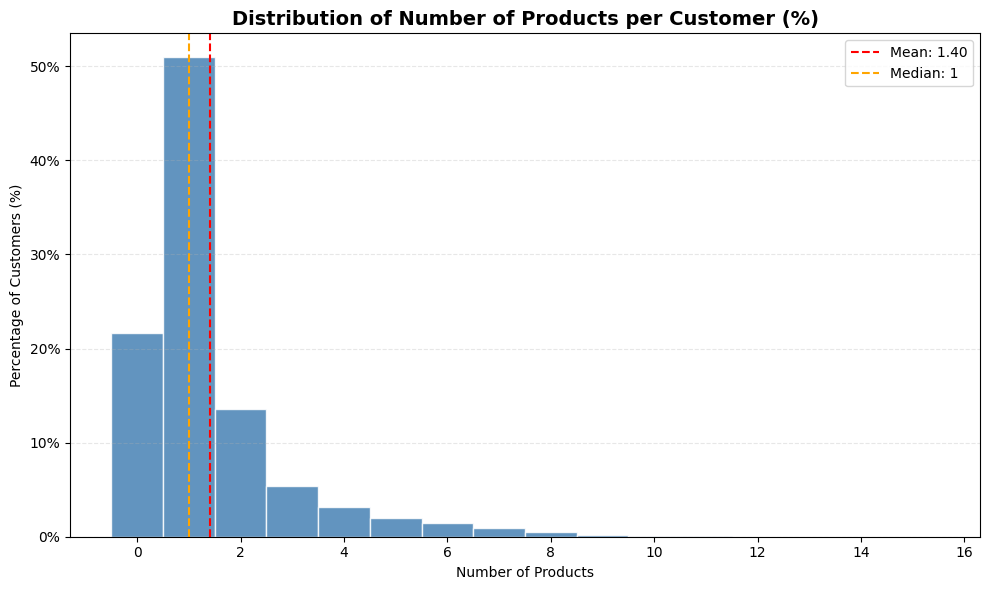

In [25]:
# product per customer
plt.figure(figsize=(10, 6))
latest['n_products'] = latest[product_cols].sum(axis=1)
weights = np.ones_like(latest['n_products']) / len(latest['n_products']) * 100
plt.hist(latest['n_products'], bins=range(0, latest['n_products'].max() + 2),
         weights=weights, color='steelblue', alpha=0.85, edgecolor='white', align='left')
plt.axvline(latest['n_products'].mean(), color='red', linestyle='--',
            label=f"Mean: {latest['n_products'].mean():.2f}")
plt.axvline(latest['n_products'].median(), color='orange', linestyle='--',
            label=f"Median: {latest['n_products'].median():.0f}")
plt.title('Distribution of Number of Products per Customer (%)', fontsize=14, fontweight='bold')
plt.xlabel('Number of Products')
plt.ylabel('Percentage of Customers (%)')
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x)}%'))
plt.legend(fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

phần lớn khách sở hữu từ 1 đến 2 sản phẩm

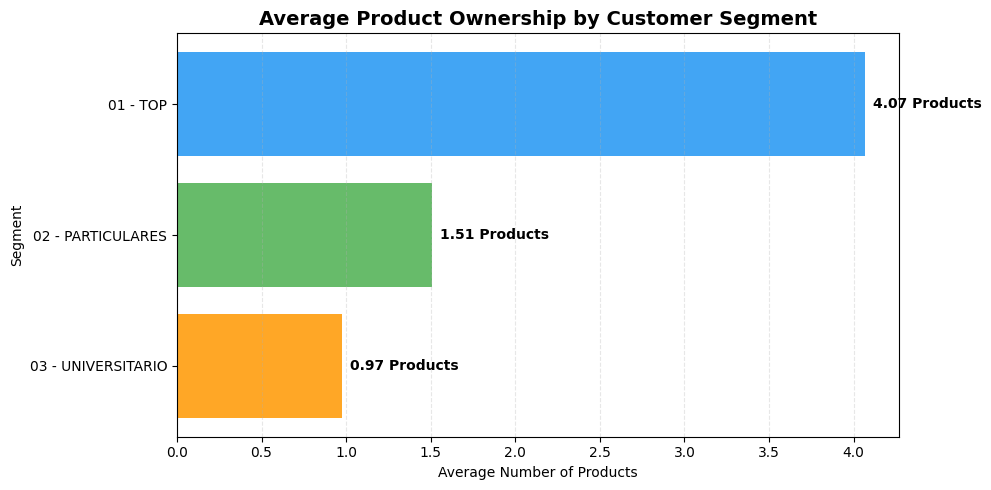

In [26]:
# average products by segment
plt.figure(figsize=(10, 5))
seg_prod = (latest.groupby('segment', observed=True)['n_products']
            .mean().sort_values(ascending=True))
bars = plt.barh(seg_prod.index, seg_prod.values,
                color=['#FF9800', '#4CAF50', '#2196F3'], alpha=0.85)
for bar, val in zip(bars, seg_prod.values):
    plt.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
             f'{val:.2f} Products', va='center', fontsize=10, fontweight='bold')
plt.title('Average Product Ownership by Customer Segment', fontsize=14, fontweight='bold')
plt.xlabel('Average Number of Products')
plt.ylabel('Segment')
plt.grid(axis='x', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

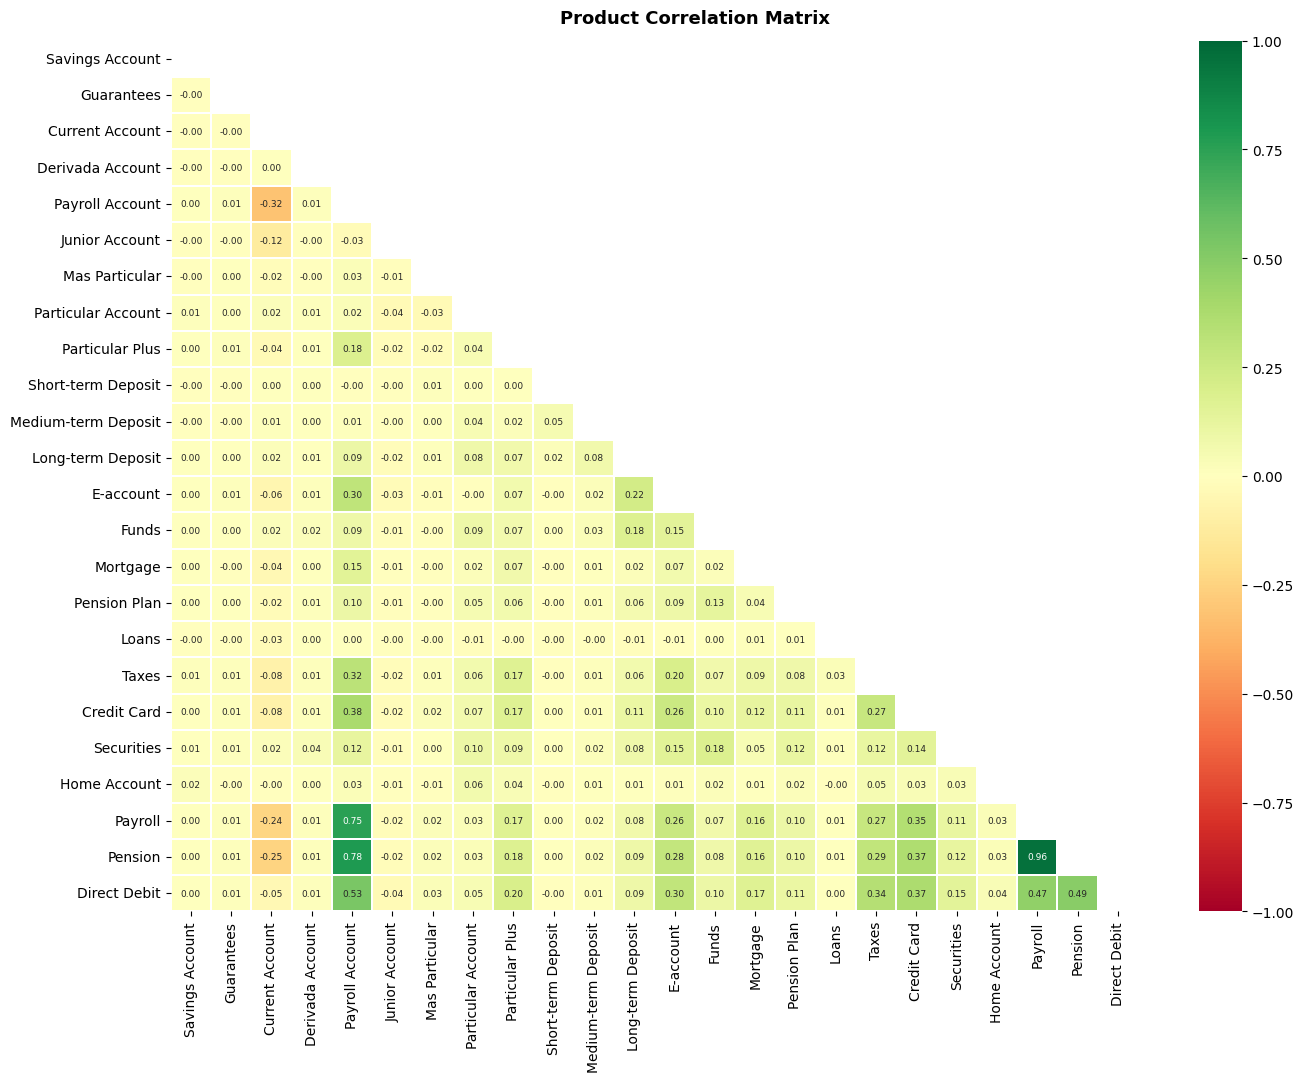

In [27]:
# product correlation
corr_matrix = latest[product_cols].corr()
corr_matrix.index   = [product_names[c] for c in product_cols]
corr_matrix.columns = [product_names[c] for c in product_cols]
fig, ax = plt.subplots(figsize=(14, 11))
fig.suptitle('Product Correlation Matrix', fontsize=13, fontweight='bold')
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, vmin=-1, vmax=1,
            linewidths=0.3, annot_kws={'size': 6.5}, ax=ax)
ax.tick_params(axis='x', rotation=90)
ax.tick_params(axis='y', rotation=0)
plt.tight_layout()
plt.savefig('phase4_4.png', dpi=150, bbox_inches='tight')
plt.show()

Mối tương quan lớn giữa Payroll, Pension và Direct Debit


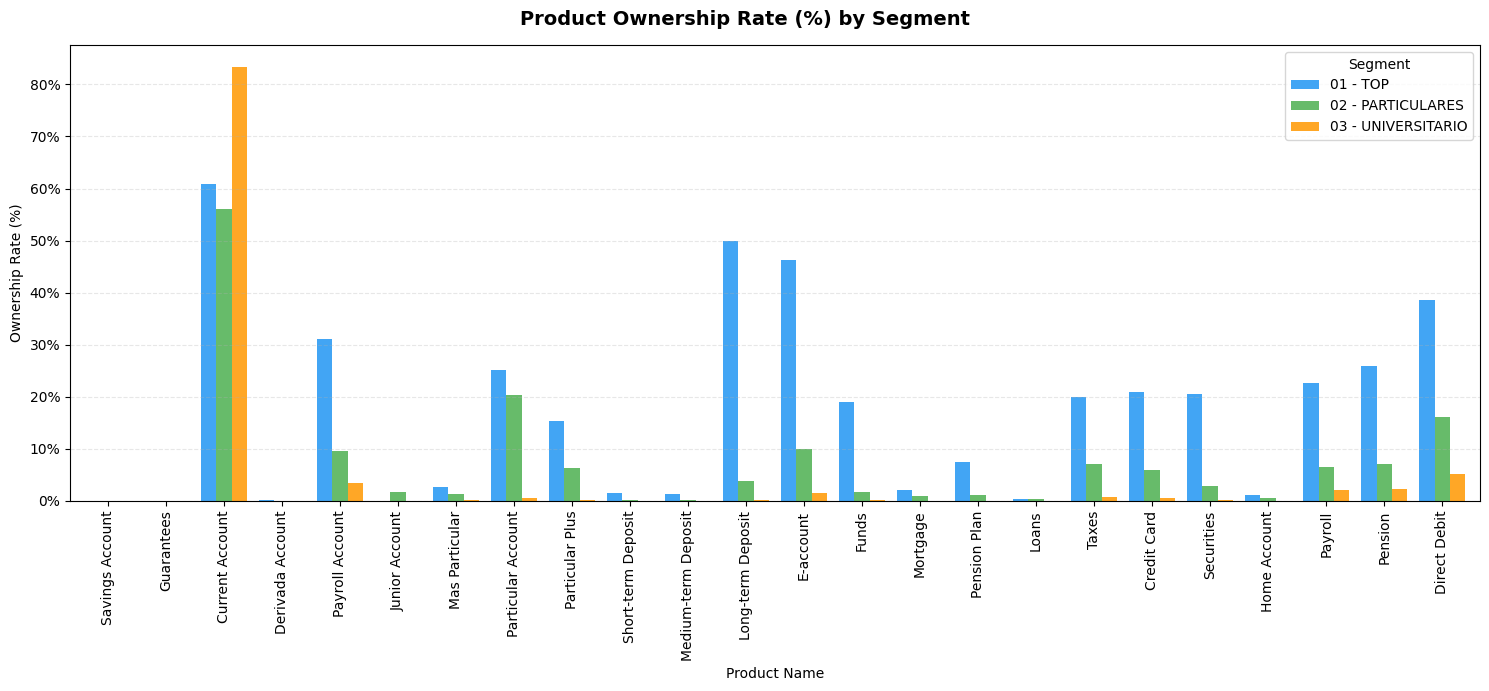

In [28]:
# product ownership rate (%) by segment
seg_product = (df_clean.groupby('segment', observed=True)[product_cols]
               .mean() * 100)
seg_product.columns = [product_names[c] for c in product_cols]
fig, ax = plt.subplots(figsize=(15, 7))
fig.suptitle('Product Ownership Rate (%) by Segment', fontsize=14, fontweight='bold')
seg_product.T.plot(kind='bar', ax=ax, alpha=0.85,
                   color=['#2196F3', '#4CAF50', '#FF9800'], width=0.8)
ax.set_ylabel('Ownership Rate (%)')
ax.set_xlabel('Product Name')
ax.tick_params(axis='x', rotation=90)
ax.legend(title='Segment', fontsize=10, loc='upper right')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x)}%'))
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.savefig('phase4_5_segment_ownership.png', dpi=150, bbox_inches='tight')
plt.show()

- Graduate tập trung ở sản phẩn cơ bản và kĩ thuật số: Current Account, E-account, Direct Debit
- Individual tập trung ở sản phẩm cơ bản: Particular Account, Payroll, Pension, Direct Debit
- VIP tập trung ở các sản phẩm đầu tư và quản lý tài sản: Long-term Deposit, Taxes, Securities, account

# TEMPORAL ANALYSIS

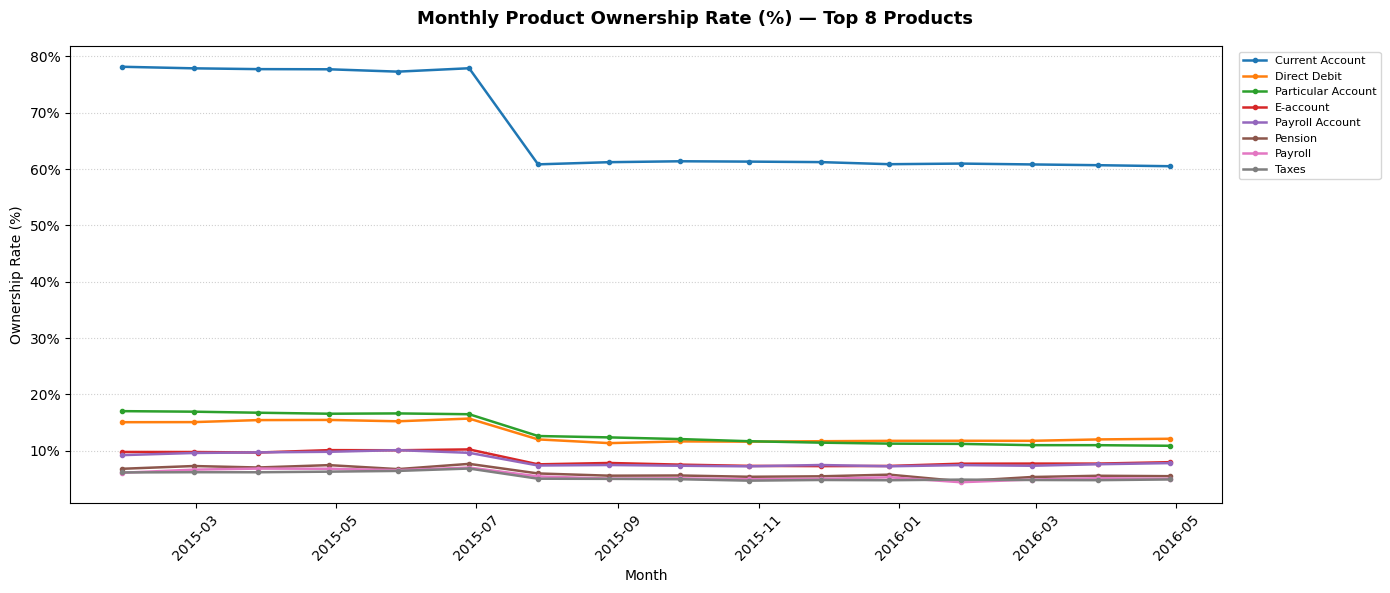

In [29]:
# monthly product ownership
monthly_product = (df_clean.groupby('date')[product_cols]
                   .mean() * 100)
monthly_product.columns = [product_names[c] for c in product_cols]
top8 = (latest[product_cols].mean()
        .rename(product_names)
        .sort_values(ascending=False)
        .head(8).index.tolist())
fig, ax = plt.subplots(figsize=(14, 6))
fig.suptitle('Monthly Product Ownership Rate (%) — Top 8 Products',
             fontsize=13, fontweight='bold')
for product in top8:
    ax.plot(monthly_product.index, monthly_product[product],
            marker='o', markersize=3, linewidth=1.8, label=product)
ax.set_xlabel('Month')
ax.set_ylabel('Ownership Rate (%)')
ax.tick_params(axis='x', rotation=45)
ax.legend(fontsize=8, bbox_to_anchor=(1.01, 1), loc='upper left')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0f}%'))
plt.grid(axis='y', linestyle=':', alpha=0.6)
plt.tight_layout()
plt.savefig('phase5_1_ownership_trend.png', dpi=150, bbox_inches='tight')
plt.show()

có sự sụt giảm mạnh vào 7/15 (có thể do lượng khách hàng mới gia nhập)

<Figure size 1000x600 with 0 Axes>

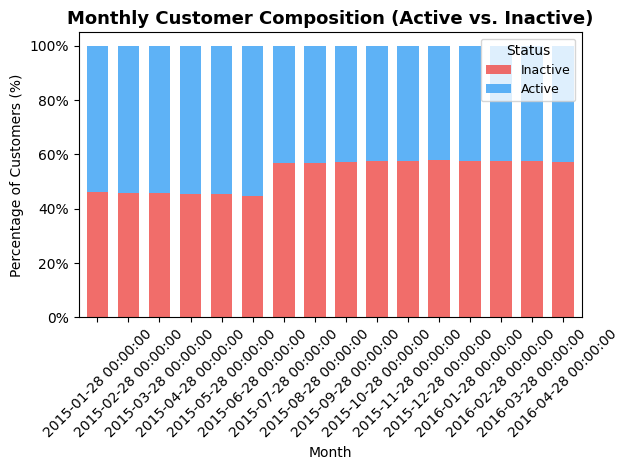

In [30]:
# monthly customer composition (active vs. inactive)
active_monthly = (df_clean.groupby(['date', 'active_customer'])
                  .size().unstack(fill_value=0)
                  .rename(columns={0.0: 'Inactive', 1.0: 'Active'}))
active_perc = active_monthly.div(active_monthly.sum(axis=1), axis=0) * 100
plt.figure(figsize=(10, 6))
ax1 = active_perc.plot(kind='bar', stacked=True,
                       color=['#EF5350', '#42A5F5'], alpha=0.85, width=0.7)
plt.title('Monthly Customer Composition (Active vs. Inactive)', fontsize=13, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Percentage of Customers (%)')
plt.xticks(rotation=45)
plt.legend(title='Status', fontsize=9, loc='upper right')
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0f}%'))
plt.tight_layout()
plt.savefig('phase5_2a_composition.png', dpi=150, bbox_inches='tight')
plt.show()

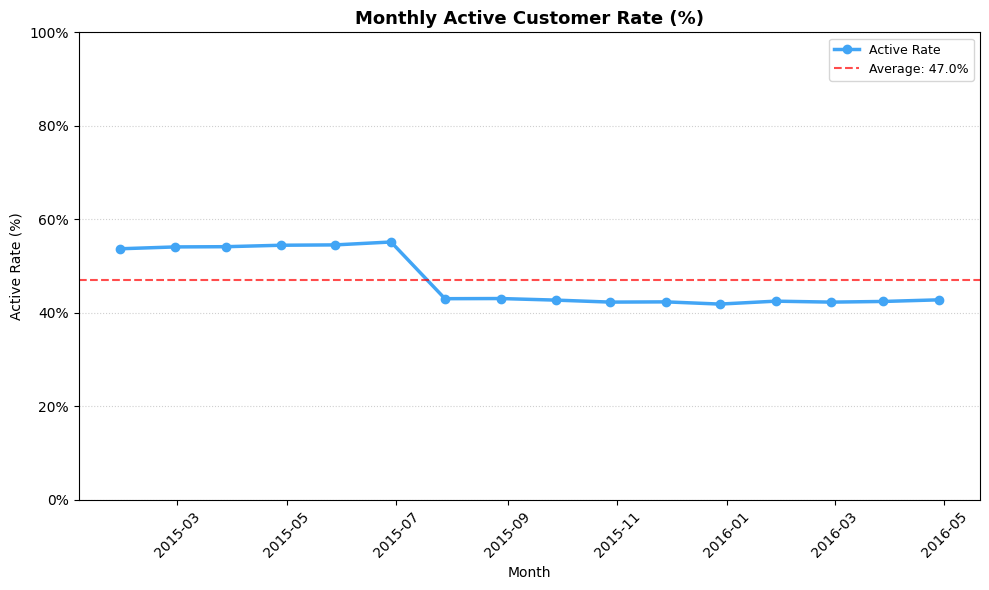

In [31]:
# monthly active customer rate
active_rate = (active_monthly['Active'] /
               (active_monthly['Active'] + active_monthly['Inactive']) * 100)
plt.figure(figsize=(10, 6))
plt.plot(active_rate.index, active_rate.values,
         marker='o', markersize=6, color='#42A5F5', linewidth=2.5, label='Active Rate')
avg_rate = active_rate.mean()
plt.axhline(avg_rate, color='red', linestyle='--', alpha=0.7,
            label=f'Average: {avg_rate:.1f}%')
plt.title('Monthly Active Customer Rate (%)', fontsize=13, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Active Rate (%)')
plt.xticks(rotation=45)
plt.ylim(0, 100)
plt.grid(axis='y', linestyle=':', alpha=0.6)
plt.legend(fontsize=9)
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0f}%'))
plt.tight_layout()
plt.savefig('phase5_2b_active_trend.png', dpi=150, bbox_inches='tight')
plt.show()

- Gần 50% khách hàng là inactive
- Số lượng KH inactive tăng mạnh vào 7/15, lý giải cho lý do lượng Product Ownership giảm mạnh ở biểu đồ trên

-> Có thể số lượng khách tăng vọt vào 7/15 là do có chương trình hấp dẫn nào đó khiến khách hàng mở thẻ

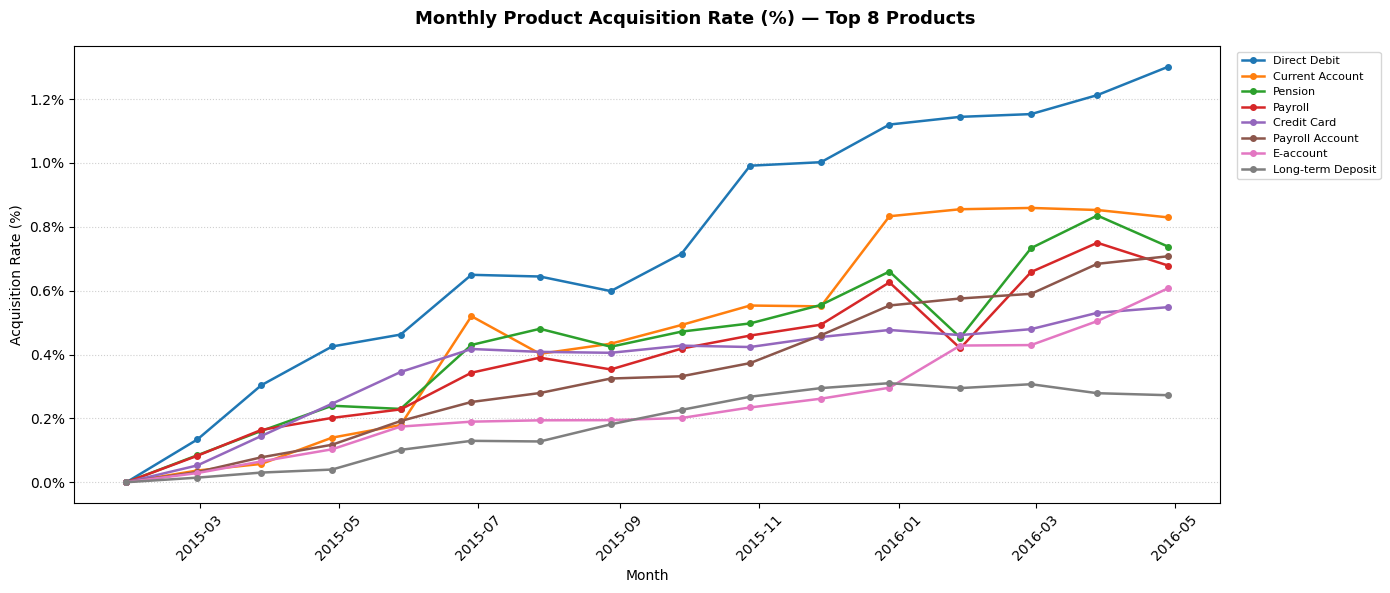

In [32]:
# product acquisition trend
df_sorted = df_clean.sort_values(['customer_id', 'date'])
product_diffs = df_sorted.groupby('customer_id')[product_cols].diff()
acquisitions = (product_diffs == 1).astype(int)
acquisitions['date'] = df_sorted['date']
monthly_acq = acquisitions.groupby('date').sum()
monthly_cust_count = df_clean.groupby('date').size()
monthly_acq_rate = monthly_acq.div(monthly_cust_count, axis=0) * 100
monthly_acq_rate.columns = [product_names[c] for c in product_cols]
top8_added = monthly_acq_rate.mean().sort_values(ascending=False).head(8).index.tolist()
fig, ax = plt.subplots(figsize=(14, 6))
fig.suptitle('Monthly Product Acquisition Rate (%) — Top 8 Products',
             fontsize=13, fontweight='bold')
for product in top8_added:
    ax.plot(monthly_acq_rate.index, monthly_acq_rate[product],
            marker='o', markersize=4, linewidth=1.8, label=product)
ax.set_xlabel('Month')
ax.set_ylabel('Acquisition Rate (%)')
ax.tick_params(axis='x', rotation=45)
ax.legend(fontsize=8, bbox_to_anchor=(1.01, 1), loc='upper left')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.1f}%'))

plt.grid(axis='y', linestyle=':', alpha=0.6)
plt.tight_layout()
plt.savefig('phase5_3_acquisition_trend.png', dpi=150, bbox_inches='tight')
plt.show()

- Đồ thị có xu hướng đi lên
- Direct Debit và Current Account luôn cao nhất => cho thấy khách hàng luôn mua sp này khi vào ngân hàng
- Pension và Payroll có correlation giống nhau => KH thường mua cùng lúc 2 sp đó

# RECOMMENDATION-ORIENTED ANALYSIS

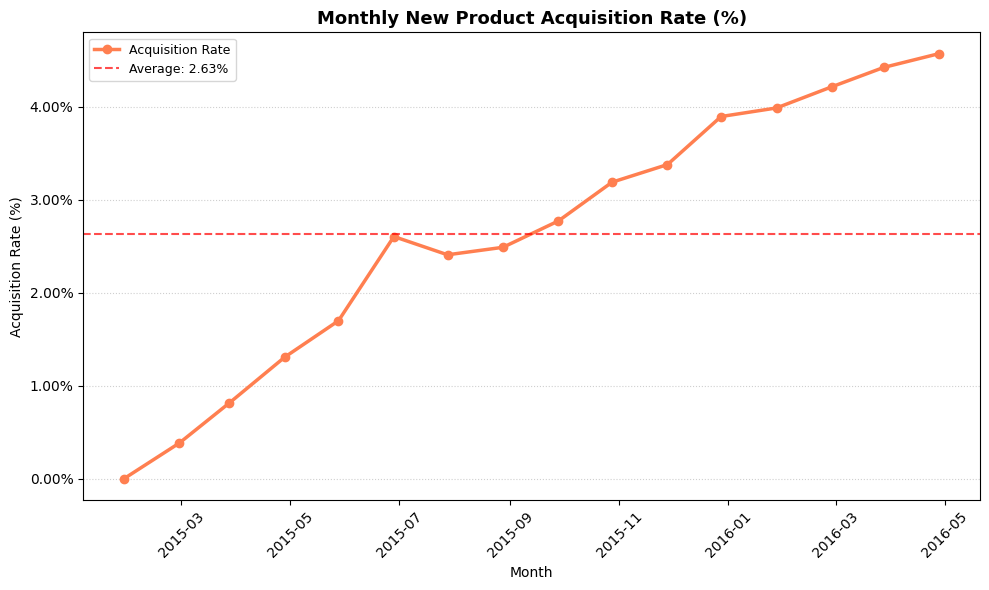

In [33]:
# monthly new product acquisition rate
product_diffs = df_sorted.groupby('customer_id')[product_cols].diff()
df_sorted['added_any'] = (product_diffs == 1).any(axis=1).astype(int)
purchase_stats = df_sorted.groupby('date')['added_any'].agg(['sum', 'count']).reset_index()
purchase_stats['buy_rate'] = (purchase_stats['sum'] / purchase_stats['count']) * 100
purchase_stats['no_change_rate'] = 100 - purchase_stats['buy_rate']
plt.figure(figsize=(10, 6))
plt.plot(purchase_stats['date'], purchase_stats['buy_rate'],
         marker='o', markersize=6, color='coral', linewidth=2.5, label='Acquisition Rate')
avg_buy_rate = purchase_stats['buy_rate'].mean()
plt.axhline(avg_buy_rate, color='red', linestyle='--', alpha=0.7,
            label=f'Average: {avg_buy_rate:.2f}%')
plt.title('Monthly New Product Acquisition Rate (%)', fontsize=13, fontweight='bold')
plt.ylabel('Acquisition Rate (%)')
plt.xlabel('Month')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle=':', alpha=0.6)
plt.legend(fontsize=9)
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.2f}%'))
plt.tight_layout()
plt.savefig('phase6_1b_trend.png', dpi=150)
plt.show()

tỉ lệ mua mới hàng tháng rất thấp (avg: 2.63%)

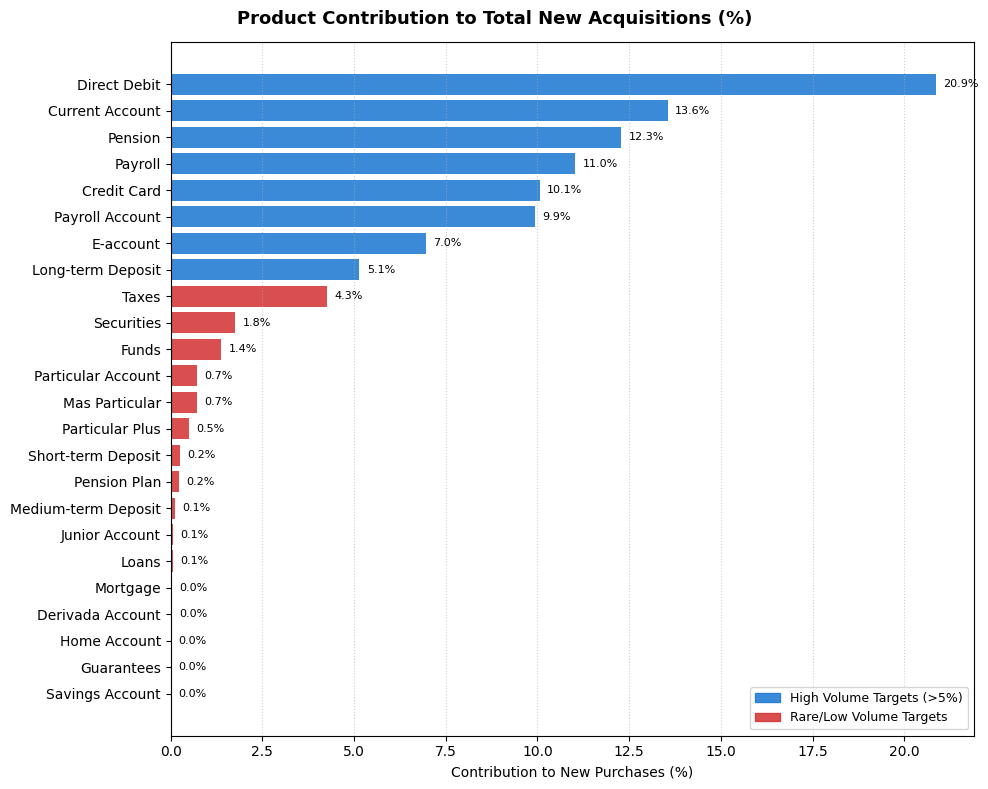

In [34]:
# product by new acuisition
df_sorted = df_clean.sort_values(['customer_id', 'date'])
product_diffs = df_sorted.groupby('customer_id')[product_cols].diff()
total_new_counts = (product_diffs == 1).sum()
total_new_counts.index = [product_names[c] for c in product_cols]
total_new_counts = total_new_counts.sort_values(ascending=True)
total_acquisitions = total_new_counts.sum()
contribution_rate = (total_new_counts / total_acquisitions) * 100
fig, ax = plt.subplots(figsize=(10, 8))
fig.suptitle('Product Contribution to Total New Acquisitions (%)',
             fontsize=13, fontweight='bold')
colors = ['#1976D2' if v > 5 else '#d32f2f' for v in contribution_rate.values]
bars = ax.barh(contribution_rate.index, contribution_rate.values, color=colors, alpha=0.85)
for bar, val in zip(bars, contribution_rate.values):
    ax.text(bar.get_width() + 0.2,
            bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=8)

ax.set_xlabel('Contribution to New Purchases (%)')
plt.grid(axis='x', linestyle=':', alpha=0.6)
ax.legend(handles=[
    plt.Rectangle((0,0),1,1, color='#1976D2', alpha=0.85, label='High Volume Targets (>5%)'),
    plt.Rectangle((0,0),1,1, color='#d32f2f', alpha=0.85, label='Rare/Low Volume Targets')
], loc='lower right', fontsize=9)
plt.tight_layout()
plt.savefig('phase6_2_popular_acquisitions.png', dpi=150, bbox_inches='tight')
plt.show()

Direct Debit (20.9%), Current Account (13.6) và Pension (12.3%) chiếm 46.8% tổng số mua mới => nên tập trung đề xuất nhóm xanh

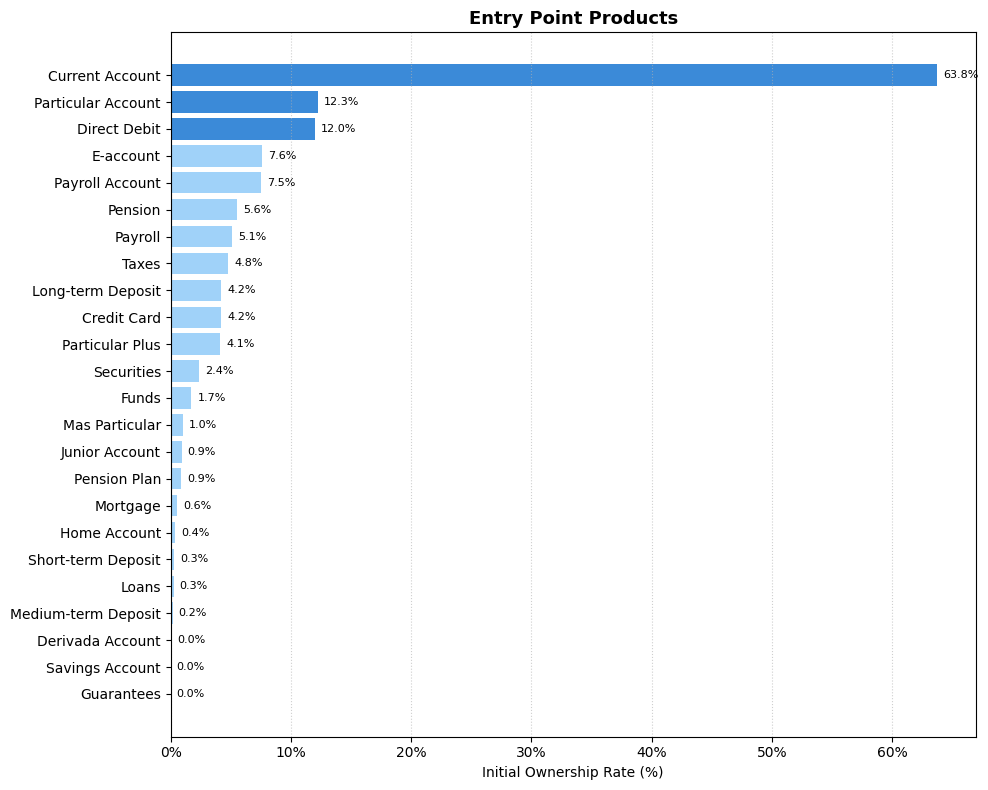

In [35]:
# customer first product
first_month = df_sorted.groupby('customer_id').first()
first_products = first_month[product_cols].sum().rename(product_names)
first_products_rate = (first_products / len(first_month)) * 100
first_products_rate = first_products_rate.sort_values(ascending=True)
plt.figure(figsize=(10, 8))
colors1 = ['#1976D2' if v > 10 else '#90CAF9' for v in first_products_rate.values]
bars1 = plt.barh(first_products_rate.index, first_products_rate.values, color=colors1, alpha=0.85)
for bar, val in zip(bars1, first_products_rate.values):
    plt.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
             f'{val:.1f}%', va='center', fontsize=8)
plt.title('Entry Point Products', fontsize=13, fontweight='bold')
plt.xlabel('Initial Ownership Rate (%)')
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0f}%'))
plt.grid(axis='x', linestyle=':', alpha=0.6)
plt.tight_layout()
plt.savefig('phase6_3a_entry_point.png', dpi=150)
plt.show()

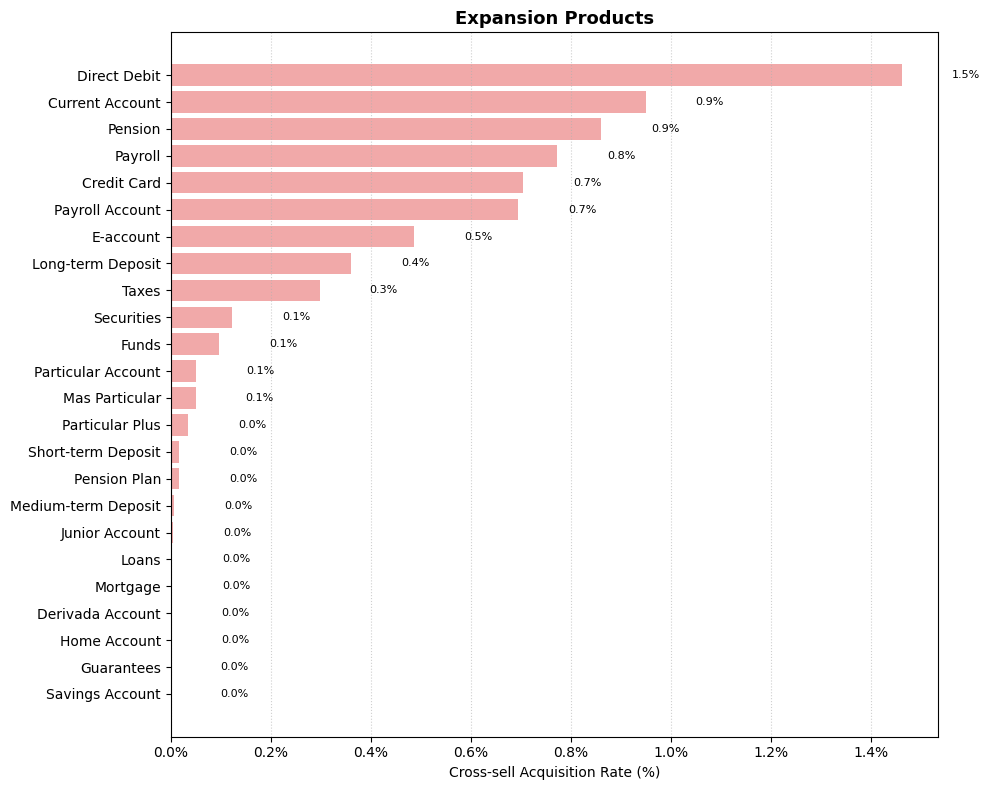

In [36]:
# customer next product
expansion_rate = (total_new_counts / len(df_clean['customer_id'].unique())) * 100
expansion_rate = expansion_rate.sort_values(ascending=True)
plt.figure(figsize=(10, 8))
colors2 = ['#E53935' if v > 2 else '#EF9A9A' for v in expansion_rate.values]
bars2 = plt.barh(expansion_rate.index, expansion_rate.values, color=colors2, alpha=0.85)
for bar, val in zip(bars2, expansion_rate.values):
    plt.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
             f'{val:.1f}%', va='center', fontsize=8)
plt.title('Expansion Products', fontsize=13, fontweight='bold')
plt.xlabel('Cross-sell Acquisition Rate (%)')
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.1f}%'))
plt.grid(axis='x', linestyle=':', alpha=0.6)
plt.tight_layout()
plt.savefig('phase6_3b_expansion.png', dpi=150)
plt.show()

- 63.8% KH bắt đầu với Current Account, tiếp theo họ sẽ mua Direct Debit (1.5%) và các gói Pension (0.9), Payroll (0.8)

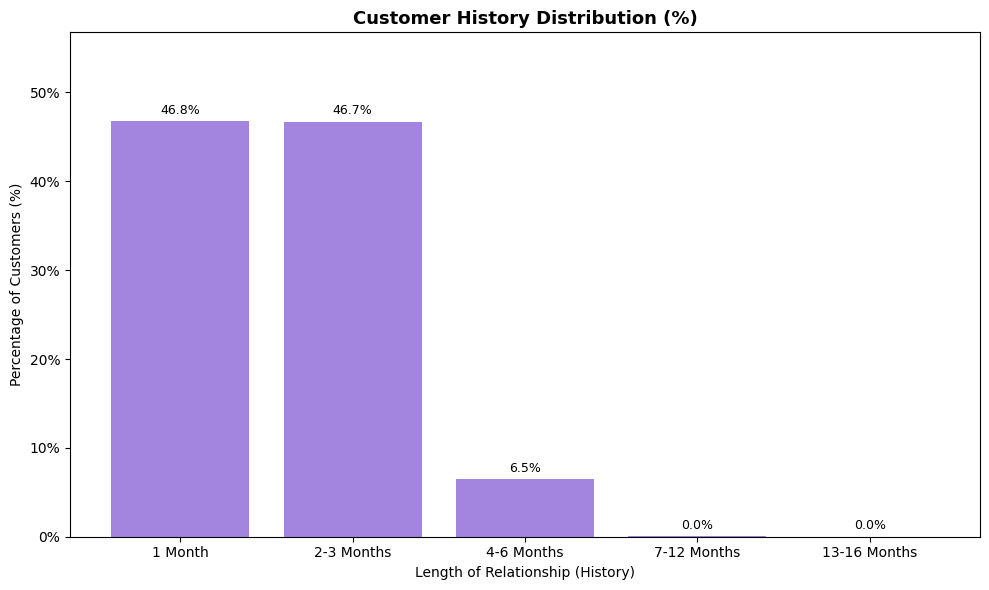

In [37]:
# customer history distribution
history_len = df_sorted.groupby('customer_id')['date'].nunique().reset_index(name='n_months')
bins = [0, 1, 3, 6, 12, 16]
labels = ['1 Month', '2-3 Months', '4-6 Months', '7-12 Months', '13-16 Months']
history_len['history_group'] = pd.cut(history_len['n_months'], bins=bins, labels=labels)
hist_dist = history_len['history_group'].value_counts(normalize=True).sort_index() * 100
plt.figure(figsize=(10, 6))
bars = plt.bar(hist_dist.index, hist_dist.values, color='mediumpurple', alpha=0.85)
for bar, val in zip(bars, hist_dist.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{val:.1f}%', ha='center', va='bottom', fontsize=9)
plt.title('Customer History Distribution (%)', fontsize=13, fontweight='bold')
plt.xlabel('Length of Relationship (History)')
plt.ylabel('Percentage of Customers (%)')
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0f}%'))
plt.ylim(0, max(hist_dist.values) + 10)

plt.tight_layout()
plt.savefig('phase6_4a_coldstart_dist.png', dpi=150)
plt.show()

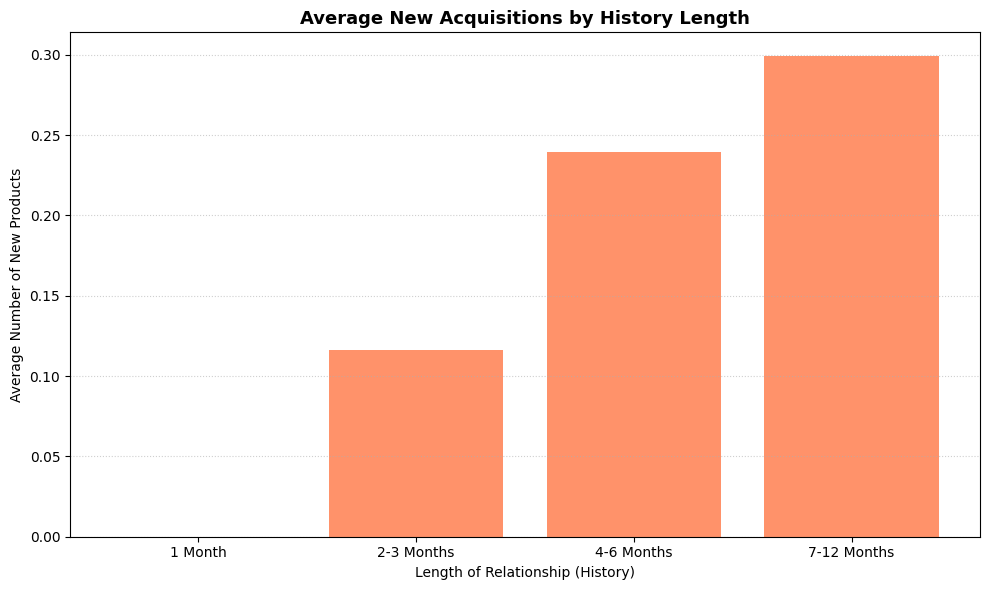

In [38]:
# new product per history
customer_purchases = (product_diffs == 1).sum(axis=1).groupby(df_sorted['customer_id']).sum().reset_index()
customer_purchases.columns = ['customer_id', 'total_acquisitions']
cold_start_df = history_len.merge(customer_purchases, on='customer_id')
avg_acq = cold_start_df.groupby('history_group', observed=True)['total_acquisitions'].mean()
plt.figure(figsize=(10, 6))
plt.bar(avg_acq.index, avg_acq.values, color='coral', alpha=0.85)
plt.title('Average New Acquisitions by History Length', fontsize=13, fontweight='bold')
plt.xlabel('Length of Relationship (History)')
plt.ylabel('Average Number of New Products')
plt.grid(axis='y', linestyle=':', alpha=0.6)
plt.tight_layout()
plt.savefig('phase6_4b_propensity.png', dpi=150)
plt.show()

- 95.5% KH có lịch sử dưới 3 tháng, nhưng nhóm ng này mua mới rất ít
- KH càng lâu thì càng càng mua nhiều sản phẩm mới => Tệp KH mang giá trị

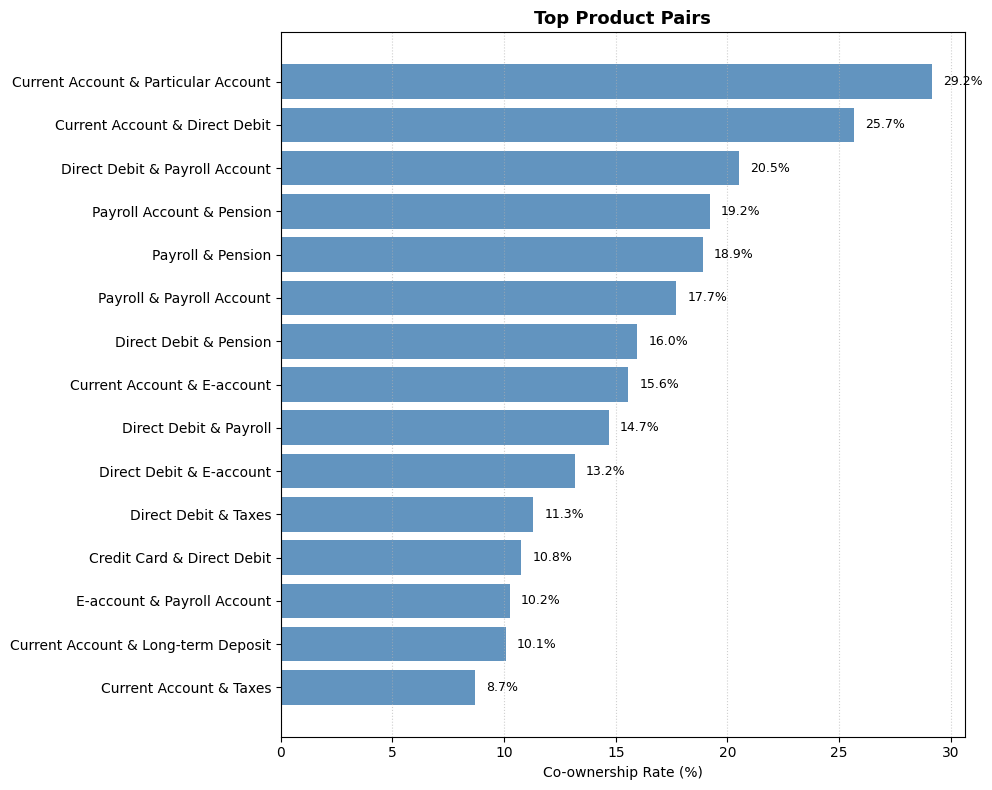

In [39]:
# top pair
from itertools import combinations
multi_product = latest[latest[product_cols].sum(axis=1) >= 2]
pair_counts = {}
for _, row in multi_product[product_cols].iterrows():
    owned = [c for c in product_cols if row[c] == 1]
    for a, b in combinations(owned, 2):
        key = tuple(sorted([product_names[a], product_names[b]]))
        pair_counts[key] = pair_counts.get(key, 0) + 1
pairs_df = (pd.DataFrame.from_dict(pair_counts, orient='index', columns=['count'])
              .reset_index()
              .rename(columns={'index': 'pair'}))
pairs_df['product_a'] = pairs_df['pair'].apply(lambda x: x[0])
pairs_df['product_b'] = pairs_df['pair'].apply(lambda x: x[1])
pairs_df = pairs_df.sort_values('count', ascending=False).head(15)
pairs_df['pair_label'] = pairs_df['product_a'] + ' & ' + pairs_df['product_b']
pairs_df['pct'] = (pairs_df['count'] / len(multi_product)) * 100
plt.figure(figsize=(10, 8))
bars = plt.barh(pairs_df['pair_label'], pairs_df['pct'], color='steelblue', alpha=0.85)
for bar, val in zip(bars, pairs_df['pct']):
    plt.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
             f'{val:.1f}%', va='center', fontsize=9)
plt.title('Top Product Pairs', fontsize=13, fontweight='bold')
plt.xlabel('Co-ownership Rate (%)')
plt.gca().invert_yaxis()
plt.grid(axis='x', linestyle=':', alpha=0.6)
plt.tight_layout()
plt.savefig('phase6_5a_product_pairs.png', dpi=150)
plt.show()

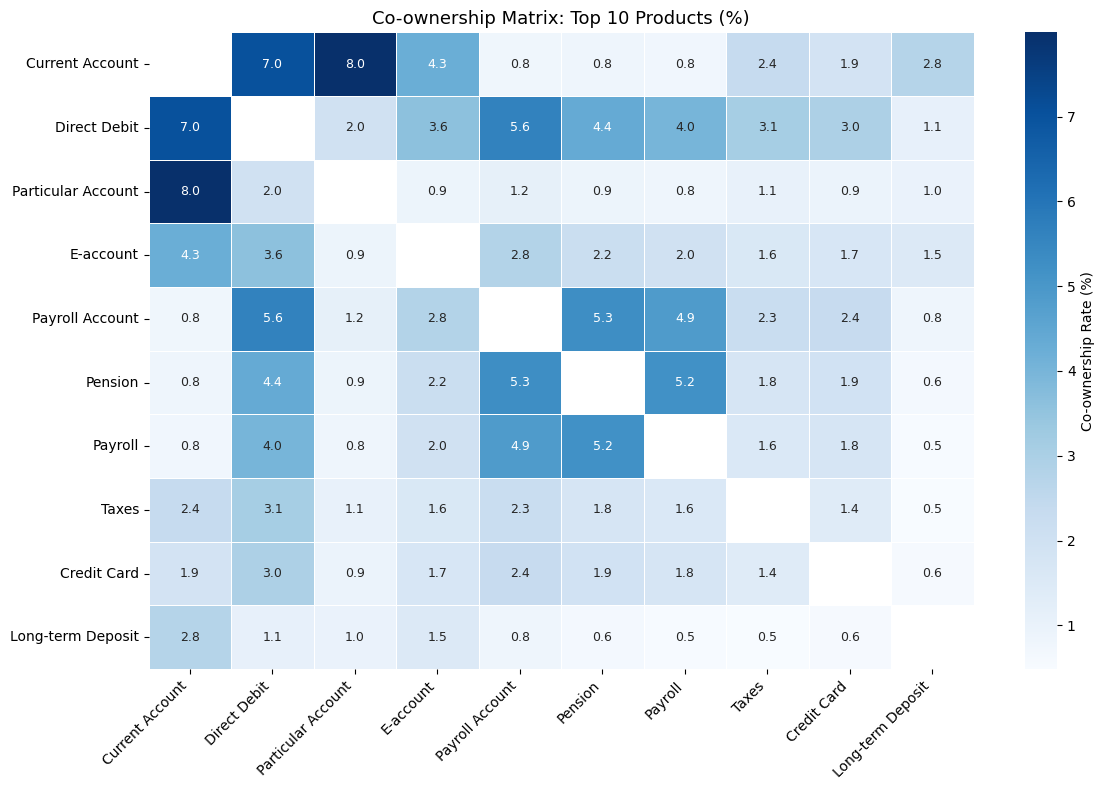

In [40]:
# co-ownership matrix
top10_prods = latest[product_cols].mean().sort_values(ascending=False).head(10).index.tolist()
co_matrix = pd.DataFrame(0, index=top10_prods, columns=top10_prods)
n_customers = len(latest)
for p1 in top10_prods:
    for p2 in top10_prods:
        if p1 != p2:
            co_matrix.loc[p1, p2] = ((latest[p1] == 1) & (latest[p2] == 1)).sum() / n_customers * 100
co_matrix.index   = [product_names[c] for c in top10_prods]
co_matrix.columns = [product_names[c] for c in top10_prods]
mask_diag = np.eye(len(co_matrix), dtype=bool)
plt.figure(figsize=(12, 8))
sns.heatmap(co_matrix, annot=True, fmt='.1f', cmap='Blues',
            mask=mask_diag, linewidths=0.5, annot_kws={'size': 9},
            cbar_kws={'label': 'Co-ownership Rate (%)'})
plt.title('Co-ownership Matrix: Top 10 Products (%)', fontsize=13)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('phase6_5b_co_matrix.png', dpi=150)
plt.show()

# Other

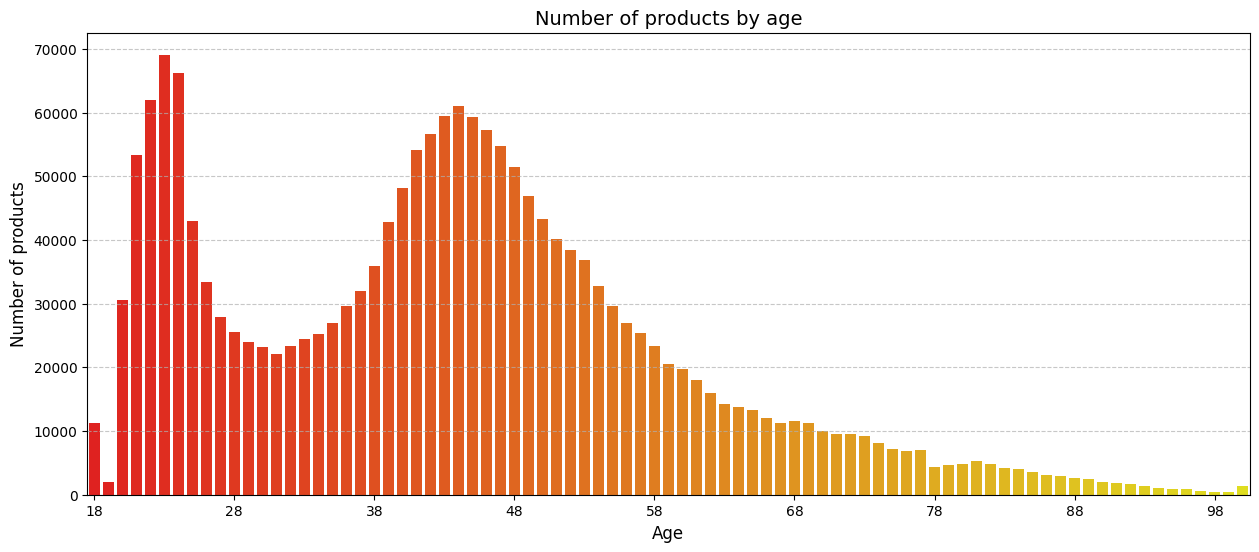

Age with most product owned:
 age  tot_products
23.0         69104
24.0         66250
22.0         62019
44.0         60989
43.0         59452
45.0         59355
46.0         57282
42.0         56652
47.0         54753
41.0         54213


In [41]:
# Number of products by age
df_clean['tot_products'] = df_clean[product_cols].sum(axis=1)
df_age_dist = df_clean.groupby('age')['tot_products'].sum().reset_index()
plt.figure(figsize=(15, 6))
sns.barplot(data=df_age_dist, x='age', y='tot_products', palette='autumn')
plt.xticks(np.arange(0, 85, 10), [int(x + 18) for x in np.arange(0, 85, 10)])
plt.title('Number of products by age', fontsize=14)
plt.xlabel('Age', fontsize=12)
plt.ylabel('Number of products', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()
print("Age with most product owned:")
print(df_age_dist.sort_values(by='tot_products', ascending=False).head(10).to_string(index=False))

binormal dítribution

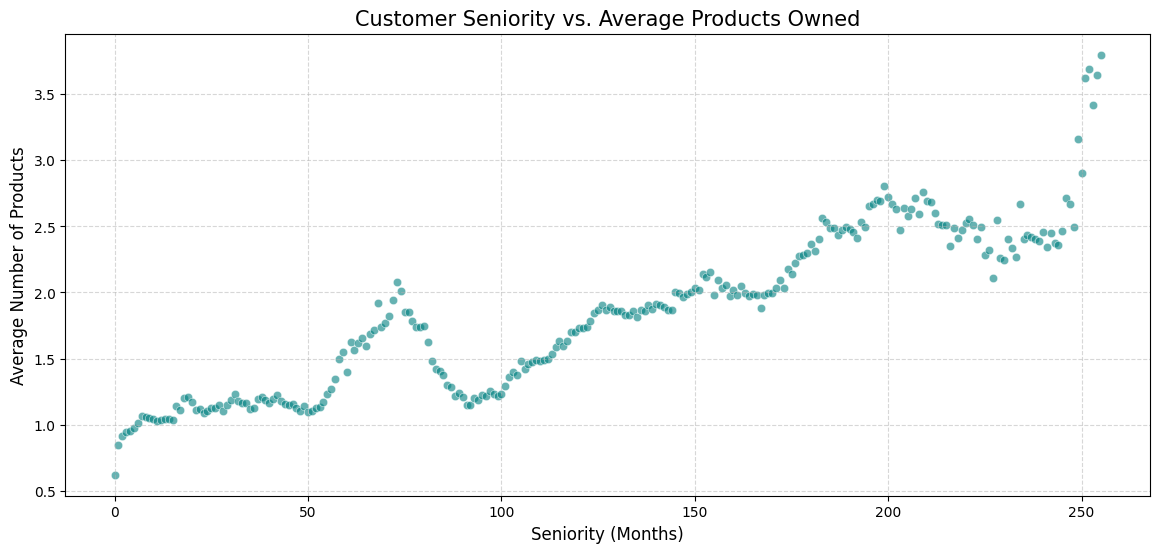

In [42]:
# Customer Seniority vs. Average Products Owned
df_trend = df_clean.groupby('seniority')['tot_products'].mean().reset_index()
plt.figure(figsize=(14, 6))
sns.scatterplot(data=df_trend, x='seniority', y='tot_products', color='teal', alpha=0.6)
plt.title('Customer Seniority vs. Average Products Owned', fontsize=15)
plt.xlabel('Seniority (Months)', fontsize=12)
plt.ylabel('Average Number of Products', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [43]:
data_test=r"/content/drive/MyDrive/test.csv"
chunk_size=200000
sample_rate=0.10
chunks=[]
for chunk in pd.read_csv(data_test, chunksize=chunk_size, low_memory=False):
  df=chunk.sample(frac=sample_rate, random_state=42)
  chunks.append(df)
df_test=pd.concat(chunks, ignore_index=True)
print(df_test.head())
print(df_test.info())

   fecha_dato  ncodpers ind_empleado pais_residencia sexo  age  fecha_alta  \
0  2016-05-28    921682            N              ES    V   25  2011-07-27   
1  2016-05-28    531130            N              ES    H   48  2005-04-29   
2  2016-05-28    958941            N              ES    H   35  2011-10-11   
3  2016-05-28    517569            N              ES    H   67  2005-02-14   
4  2016-05-28    722258            N              ES    V   67  2007-10-01   

   ind_nuevo  antiguedad  indrel  ... ind_hip_fin_ult1 ind_plan_fin_ult1  \
0        0.0          58     1.0  ...                0                 0   
1        0.0         133     1.0  ...                0                 0   
2        0.0          55     1.0  ...                0                 0   
3        0.0         135     1.0  ...                0                 0   
4        0.0         103     1.0  ...                0                 0   

  ind_pres_fin_ult1 ind_reca_fin_ult1 ind_tjcr_fin_ult1 ind_valo_fin_ult1 

In [44]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 93145 entries, 0 to 93144
Data columns (total 48 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   fecha_dato             93145 non-null  object 
 1   ncodpers               93145 non-null  int64  
 2   ind_empleado           93145 non-null  object 
 3   pais_residencia        93145 non-null  object 
 4   sexo                   93145 non-null  object 
 5   age                    93145 non-null  int64  
 6   fecha_alta             93145 non-null  object 
 7   ind_nuevo              93145 non-null  float64
 8   antiguedad             93145 non-null  int64  
 9   indrel                 93145 non-null  float64
 10  ult_fec_cli_1t         177 non-null    object 
 11  indrel_1mes            92783 non-null  object 
 12  tiprel_1mes            92783 non-null  object 
 13  indresi                93145 non-null  object 
 14  indext                 93145 non-null  object 
 15  co

In [45]:
df_test.rename(columns={
    'fecha_dato': 'date',
    'ncodpers': 'customer_id',
    'ind_empleado': 'employee_index',
    'pais_residencia': 'country',
    'sexo': 'gender',
    'age' : 'age',
    'fecha_alta': 'join_date',
    'ind_nuevo': 'new_customer',
    'antiguedad': 'seniority',
    'indrel': 'customer_type',
    'ult_fec_cli_1t': 'last_primary_date',
    'indrel_1mes': 'customer_relation_month_start',
    'tiprel_1mes': 'relation_type',
    'indresi': 'resident',
    'indext': 'foreigner',
    'conyuemp': 'employee_spouse',
    'canal_entrada': 'join_channel',
    'indfall': 'deceased',
    'tipodom': 'address_type',
    'cod_prov': 'province_code',
    'nomprov': 'province',
    'ind_actividad_cliente': 'active_customer',
    'renta': 'income',
    'segmento': 'segment',
    'ind_ahor_fin_ult1': 'product_savings_account',
    'ind_aval_fin_ult1': 'product_guarantees',
    'ind_cco_fin_ult1': 'product_current_account',
    'ind_cder_fin_ult1': 'product_derivada_account',
    'ind_cno_fin_ult1': 'product_payroll_account',
    'ind_ctju_fin_ult1': 'product_junior_account',
    'ind_ctma_fin_ult1': 'product_mas_particular_account',
    'ind_ctop_fin_ult1': 'product_particular_account',
    'ind_ctpp_fin_ult1': 'product_particular_plus_account',
    'ind_deco_fin_ult1': 'product_short_term_deposit',
    'ind_deme_fin_ult1': 'product_medium_term_deposit',
    'ind_dela_fin_ult1': 'product_long_term_deposit',
    'ind_ecue_fin_ult1': 'product_e_account',
    'ind_fond_fin_ult1': 'product_funds',
    'ind_hip_fin_ult1': 'product_mortgage',
    'ind_plan_fin_ult1': 'product_pension_plan',
    'ind_pres_fin_ult1': 'product_loans',
    'ind_reca_fin_ult1': 'product_taxes',
    'ind_tjcr_fin_ult1': 'product_credit_card',
    'ind_valo_fin_ult1': 'product_securities',
    'ind_viv_fin_ult1': 'product_home_account',
    'ind_nomina_ult1': 'product_payroll',
    'ind_nom_pens_ult1': 'product_pension',
    'ind_recibo_ult1': 'product_direct_debit'
}, inplace=True)

In [46]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 93145 entries, 0 to 93144
Data columns (total 48 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   date                             93145 non-null  object 
 1   customer_id                      93145 non-null  int64  
 2   employee_index                   93145 non-null  object 
 3   country                          93145 non-null  object 
 4   gender                           93145 non-null  object 
 5   age                              93145 non-null  int64  
 6   join_date                        93145 non-null  object 
 7   new_customer                     93145 non-null  float64
 8   seniority                        93145 non-null  int64  
 9   customer_type                    93145 non-null  float64
 10  last_primary_date                177 non-null    object 
 11  customer_relation_month_start    92783 non-null  object 
 12  relation_type     

In [47]:
product_col_test=[]
for c in df_test.columns:
  if c.startswith('product_'):
    product_col_test.append(c)
print(product_col_test)

['product_savings_account', 'product_guarantees', 'product_current_account', 'product_derivada_account', 'product_payroll_account', 'product_junior_account', 'product_mas_particular_account', 'product_particular_account', 'product_particular_plus_account', 'product_short_term_deposit', 'product_medium_term_deposit', 'product_long_term_deposit', 'product_e_account', 'product_funds', 'product_mortgage', 'product_pension_plan', 'product_loans', 'product_taxes', 'product_credit_card', 'product_securities', 'product_home_account', 'product_payroll', 'product_pension', 'product_direct_debit']


In [48]:
df_test[product_col_test]=df_test[product_col_test].apply(pd.to_numeric, errors='coerce').fillna(0).astype('int8')
df_test['age']=pd.to_numeric(df_test['age'], errors='coerce').astype('float32')
df_test['income']=pd.to_numeric(df_test['income'], errors='coerce').astype('float32')
df_test['date']=pd.to_datetime(df_test['date'])
df_test['join_date']=pd.to_datetime(df_test['join_date'])
df_test['last_primary_date']=pd.to_datetime(df_test['last_primary_date'])
df_test['seniority']=pd.to_numeric(df_test['seniority'], errors='coerce').astype('float32')
df_test['customer_id']=df_test['customer_id'].astype('int32')

In [49]:
print(df_test.shape)
df_test.head(10)

(93145, 48)


,date,customer_id,employee_index,country,gender,age,join_date,new_customer,seniority,customer_type,...,product_mortgage,product_pension_plan,product_loans,product_taxes,product_credit_card,product_securities,product_home_account,product_payroll,product_pension,product_direct_debit
0,2016-05-28,921682,N,ES,V,25.0,2011-07-27,0.0,58.0,1.0,...,0,0,0,0,0,0,0,0,0,0
1,2016-05-28,531130,N,ES,H,48.0,2005-04-29,0.0,133.0,1.0,...,0,0,0,0,1,0,0,0,0,0
2,2016-05-28,958941,N,ES,H,35.0,2011-10-11,0.0,55.0,1.0,...,0,0,0,0,0,0,0,0,0,0
3,2016-05-28,517569,N,ES,H,67.0,2005-02-14,0.0,135.0,1.0,...,0,0,0,0,0,0,0,0,0,0
4,2016-05-28,722258,N,ES,V,67.0,2007-10-01,0.0,103.0,1.0,...,0,0,0,0,0,0,0,0,0,0
5,2016-05-28,646779,N,ES,H,34.0,2006-10-09,0.0,115.0,1.0,...,0,0,0,1,0,0,0,0,0,0
6,2016-05-28,886316,N,ES,V,50.0,2010-07-20,0.0,70.0,1.0,...,0,0,0,0,0,0,0,0,0,1
7,2016-05-28,794192,N,VE,V,44.0,2008-09-15,0.0,92.0,1.0,...,0,0,0,0,0,0,0,0,0,0
8,2016-05-28,892384,N,ES,H,44.0,2010-09-23,0.0,68.0,1.0,...,0,0,0,0,0,0,0,0,0,0
9,2016-05-28,650036,N,ES,H,38.0,2006-10-20,0.0,115.0,1.0,...,0,0,0,0,0,0,0,0,0,0


In [50]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 93145 entries, 0 to 93144
Data columns (total 48 columns):
 #   Column                           Non-Null Count  Dtype         
---  ------                           --------------  -----         
 0   date                             93145 non-null  datetime64[ns]
 1   customer_id                      93145 non-null  int32         
 2   employee_index                   93145 non-null  object        
 3   country                          93145 non-null  object        
 4   gender                           93145 non-null  object        
 5   age                              93145 non-null  float32       
 6   join_date                        93145 non-null  datetime64[ns]
 7   new_customer                     93145 non-null  float64       
 8   seniority                        93145 non-null  float32       
 9   customer_type                    93145 non-null  float64       
 10  last_primary_date                177 non-null    datetime6

In [51]:
missing_test=df_test.isnull().sum()
missing_test_pct=(missing_test/len(df_test) *100).round(2)
report=pd.DataFrame({
    'missing': missing_test,
    'missing_pct':missing_test_pct
}).query('missing>0').sort_values('missing_pct', ascending=False)
print(report)

                               missing  missing_pct
employee_spouse                  93139        99.99
last_primary_date                92968        99.81
income                           22880        24.56
segment                            669         0.72
join_channel                       634         0.68
province                           400         0.43
province_code                      400         0.43
customer_relation_month_start      362         0.39
relation_type                      362         0.39


In [52]:
df_test['seniority']=df_test['seniority'].clip(lower=0)
print(df_test['seniority'])

0         58.0
1        133.0
2         55.0
3        135.0
4        103.0
         ...  
93140     31.0
93141     34.0
93142     26.0
93143     32.0
93144     31.0
Name: seniority, Length: 93145, dtype: float32


In [53]:
invalid_age=(df_test['age']<18)|(df_test['age']>100)
print(len(invalid_age))
df_test['age']= df_test['age'].clip(lower=18, upper=100)
print(df_test['age'])

93145
0        25.0
1        48.0
2        35.0
3        67.0
4        67.0
         ... 
93140    22.0
93141    25.0
93142    55.0
93143    22.0
93144    22.0
Name: age, Length: 93145, dtype: float32


In [54]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 93145 entries, 0 to 93144
Data columns (total 48 columns):
 #   Column                           Non-Null Count  Dtype         
---  ------                           --------------  -----         
 0   date                             93145 non-null  datetime64[ns]
 1   customer_id                      93145 non-null  int32         
 2   employee_index                   93145 non-null  object        
 3   country                          93145 non-null  object        
 4   gender                           93145 non-null  object        
 5   age                              93145 non-null  float32       
 6   join_date                        93145 non-null  datetime64[ns]
 7   new_customer                     93145 non-null  float64       
 8   seniority                        93145 non-null  float32       
 9   customer_type                    93145 non-null  float64       
 10  last_primary_date                177 non-null    datetime6

In [55]:
df_test[product_col_test].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 93145 entries, 0 to 93144
Data columns (total 24 columns):
 #   Column                           Non-Null Count  Dtype
---  ------                           --------------  -----
 0   product_savings_account          93145 non-null  int8 
 1   product_guarantees               93145 non-null  int8 
 2   product_current_account          93145 non-null  int8 
 3   product_derivada_account         93145 non-null  int8 
 4   product_payroll_account          93145 non-null  int8 
 5   product_junior_account           93145 non-null  int8 
 6   product_mas_particular_account   93145 non-null  int8 
 7   product_particular_account       93145 non-null  int8 
 8   product_particular_plus_account  93145 non-null  int8 
 9   product_short_term_deposit       93145 non-null  int8 
 10  product_medium_term_deposit      93145 non-null  int8 
 11  product_long_term_deposit        93145 non-null  int8 
 12  product_e_account                93145 non-nul

In [56]:
df_test['address_type']=df_test['address_type'].astype('float32')
df_test['province_code']=df_test['province_code'].astype('float32')
df_test['customer_type']=df_test['customer_type'].astype('float32')
df_test['active_customer']=df_test['active_customer'].astype('float32')
df_test['new_customer']=df_test['new_customer'].astype('float32')
df_test['gender']=df_test['gender'].astype(str).str.strip().replace('nan', np.nan)
df_test['gender']=df_test['gender'].where(df_test['gender'].isin(['H','V']), np.nan)

In [57]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 93145 entries, 0 to 93144
Data columns (total 48 columns):
 #   Column                           Non-Null Count  Dtype         
---  ------                           --------------  -----         
 0   date                             93145 non-null  datetime64[ns]
 1   customer_id                      93145 non-null  int32         
 2   employee_index                   93145 non-null  object        
 3   country                          93145 non-null  object        
 4   gender                           93145 non-null  object        
 5   age                              93145 non-null  float32       
 6   join_date                        93145 non-null  datetime64[ns]
 7   new_customer                     93145 non-null  float32       
 8   seniority                        93145 non-null  float32       
 9   customer_type                    93145 non-null  float32       
 10  last_primary_date                177 non-null    datetime6

In [58]:
dup_customer_month=df_test.duplicated(subset=['customer_id', 'date']).sum()
if dup_customer_month>0:
  print(dup_customer_month)
  df_test.drop_duplicates(subset=['customer_id', 'date'], keep='last')
else:
  print("0 dups")

0 dups


In [59]:
df_test.drop(columns={'employee_spouse'})

,date,customer_id,employee_index,country,gender,age,join_date,new_customer,seniority,customer_type,...,product_mortgage,product_pension_plan,product_loans,product_taxes,product_credit_card,product_securities,product_home_account,product_payroll,product_pension,product_direct_debit
0,2016-05-28,921682,N,ES,V,25.0,2011-07-27,0.0,58.0,1.0,...,0,0,0,0,0,0,0,0,0,0
1,2016-05-28,531130,N,ES,H,48.0,2005-04-29,0.0,133.0,1.0,...,0,0,0,0,1,0,0,0,0,0
2,2016-05-28,958941,N,ES,H,35.0,2011-10-11,0.0,55.0,1.0,...,0,0,0,0,0,0,0,0,0,0
3,2016-05-28,517569,N,ES,H,67.0,2005-02-14,0.0,135.0,1.0,...,0,0,0,0,0,0,0,0,0,0
4,2016-05-28,722258,N,ES,V,67.0,2007-10-01,0.0,103.0,1.0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
93140,2016-05-28,1211697,N,ES,H,22.0,2013-10-30,0.0,31.0,1.0,...,0,0,0,0,0,0,0,0,0,0
93141,2016-05-28,1145487,N,ES,H,25.0,2013-07-23,0.0,34.0,1.0,...,0,0,0,0,0,0,0,0,0,0
93142,2016-05-28,1246495,N,ES,H,55.0,2014-03-04,0.0,26.0,1.0,...,0,0,0,0,0,0,0,0,0,0
93143,2016-05-28,1178076,N,ES,V,22.0,2013-09-18,0.0,32.0,1.0,...,0,0,0,0,0,0,0,0,0,0


In [60]:
numeric_cols = []
binary_cols = []
categorical_cols = []

for col in df_clean.columns:

    unique_vals = df_clean[col].dropna().unique()

    # binary columns
    if len(unique_vals) == 2:
        binary_cols.append(col)

    # numeric columns
    elif pd.api.types.is_numeric_dtype(df_clean[col]):
        numeric_cols.append(col)

    # categorical columns
    else:
        categorical_cols.append(col)

In [61]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 93145 entries, 0 to 93144
Data columns (total 48 columns):
 #   Column                           Non-Null Count  Dtype         
---  ------                           --------------  -----         
 0   date                             93145 non-null  datetime64[ns]
 1   customer_id                      93145 non-null  int32         
 2   employee_index                   93145 non-null  object        
 3   country                          93145 non-null  object        
 4   gender                           93145 non-null  object        
 5   age                              93145 non-null  float32       
 6   join_date                        93145 non-null  datetime64[ns]
 7   new_customer                     93145 non-null  float32       
 8   seniority                        93145 non-null  float32       
 9   customer_type                    93145 non-null  float32       
 10  last_primary_date                177 non-null    datetime6

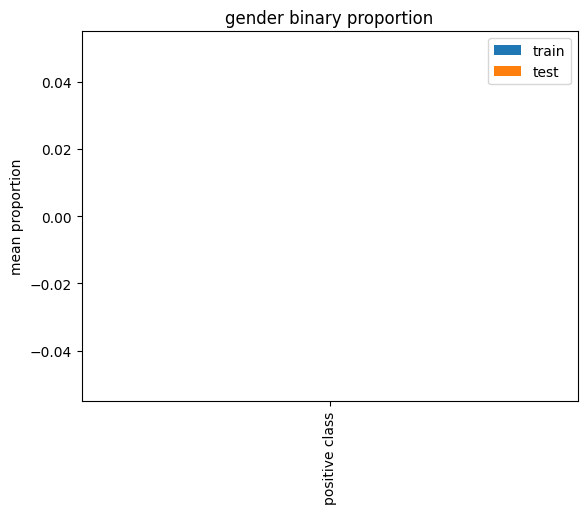

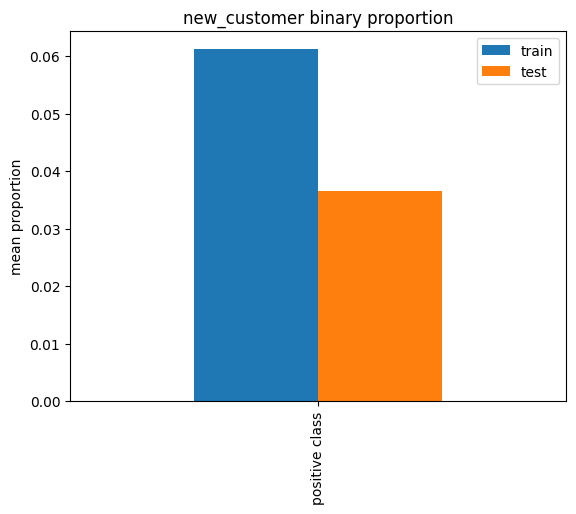

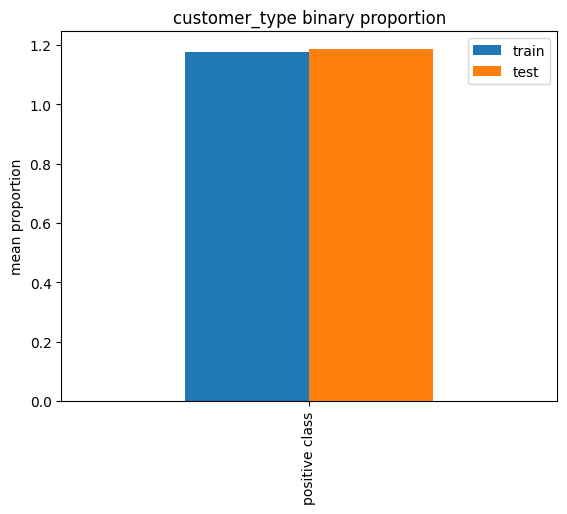

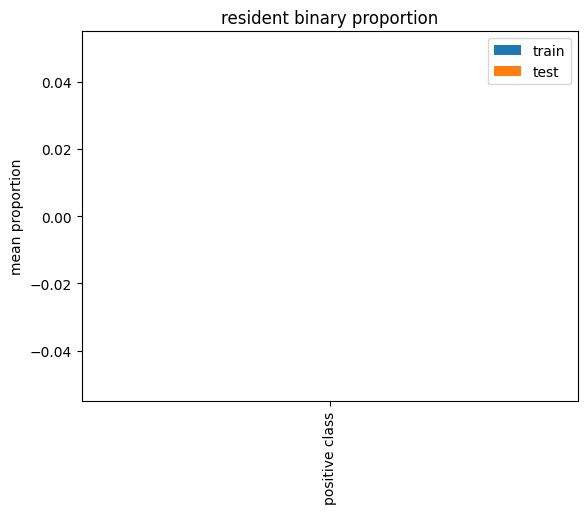

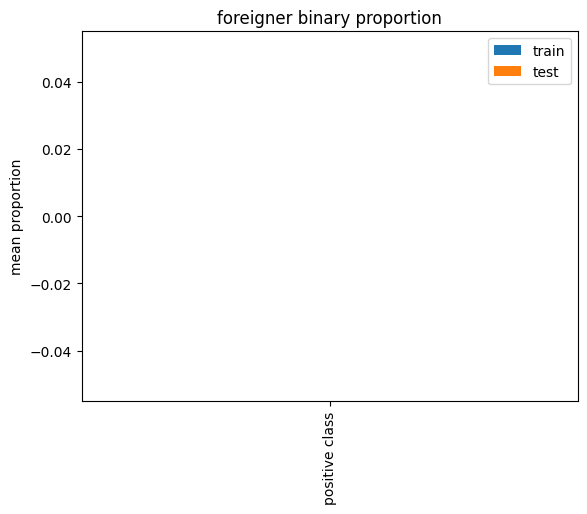

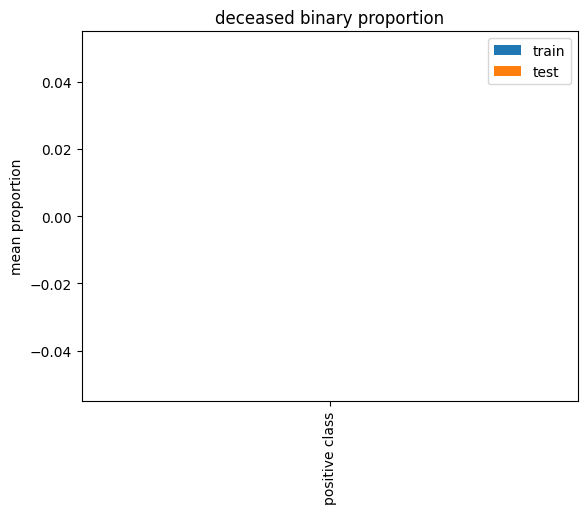

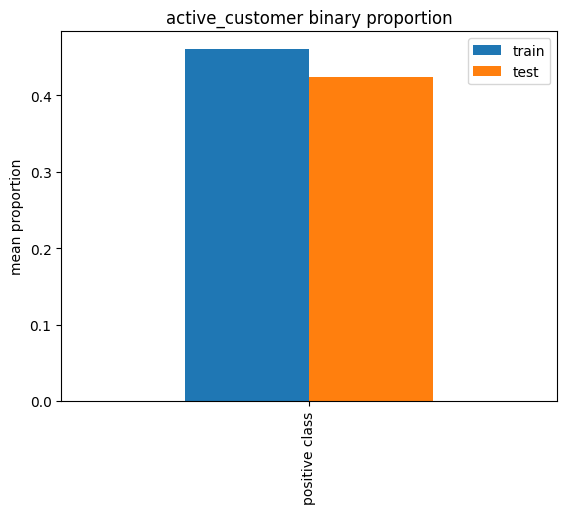

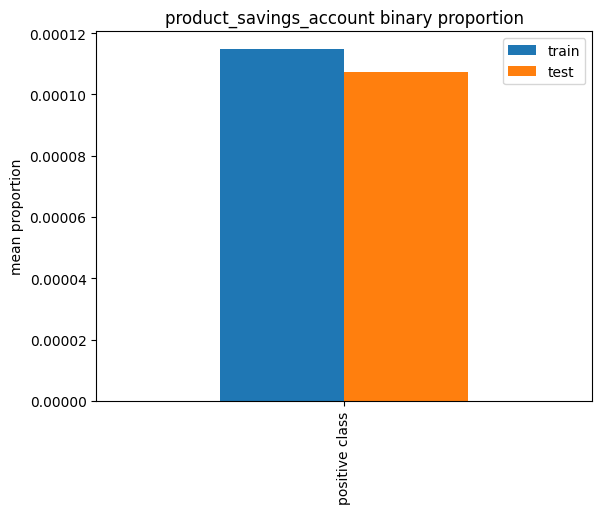

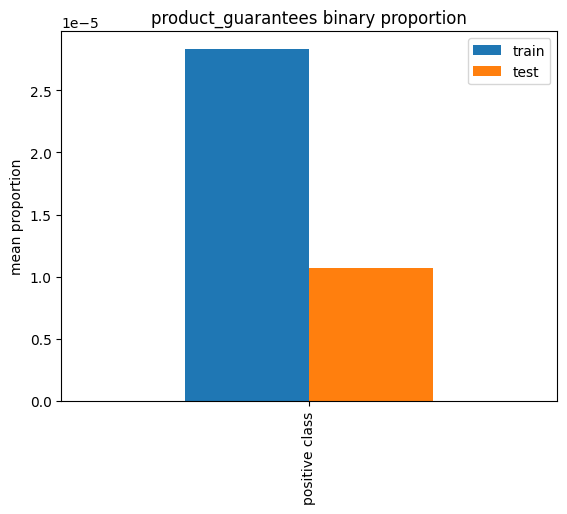

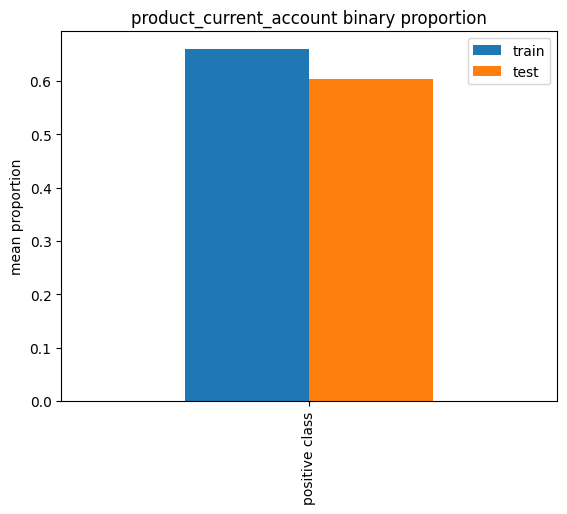

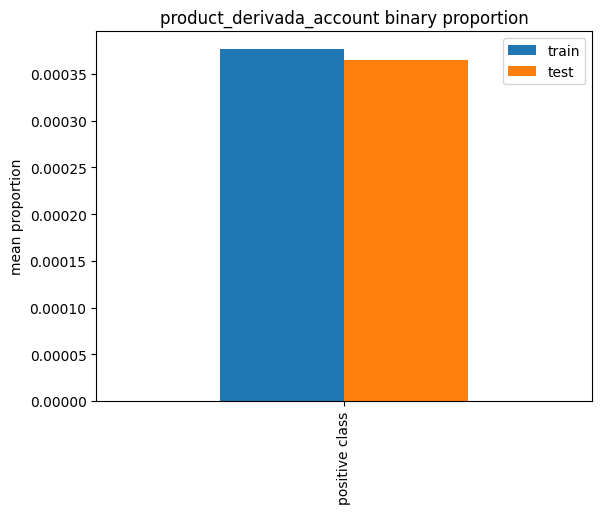

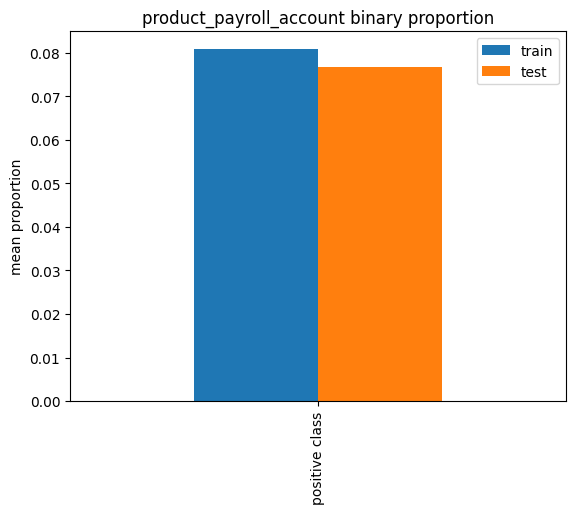

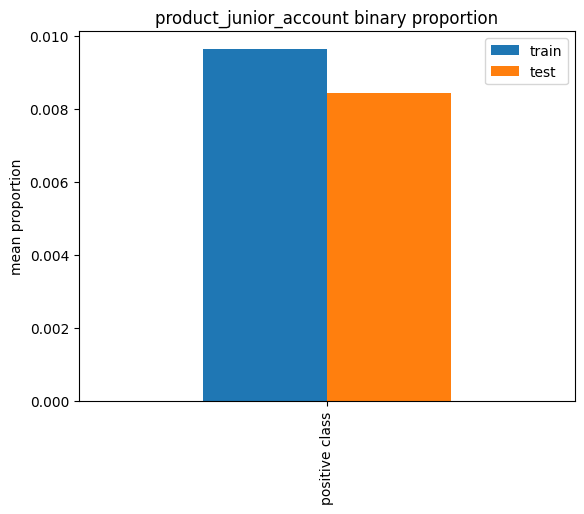

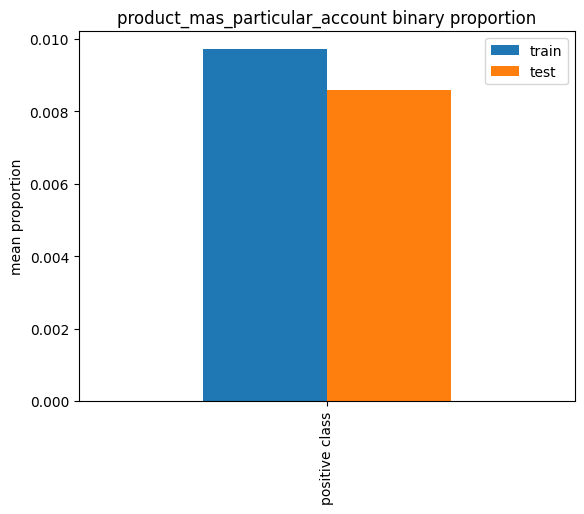

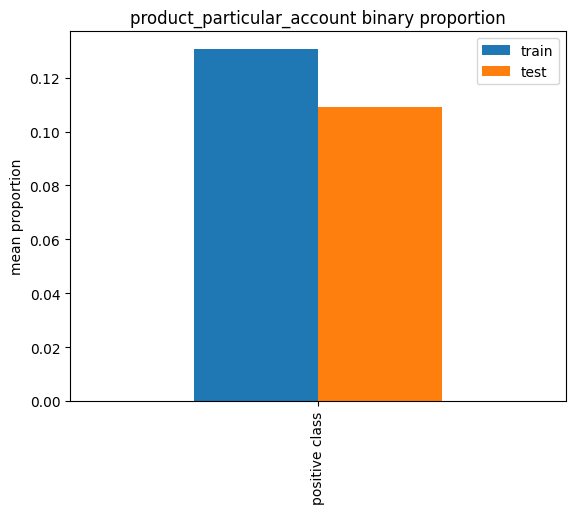

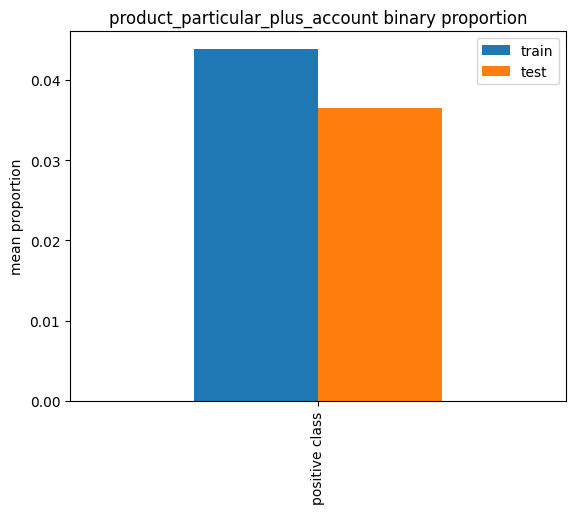

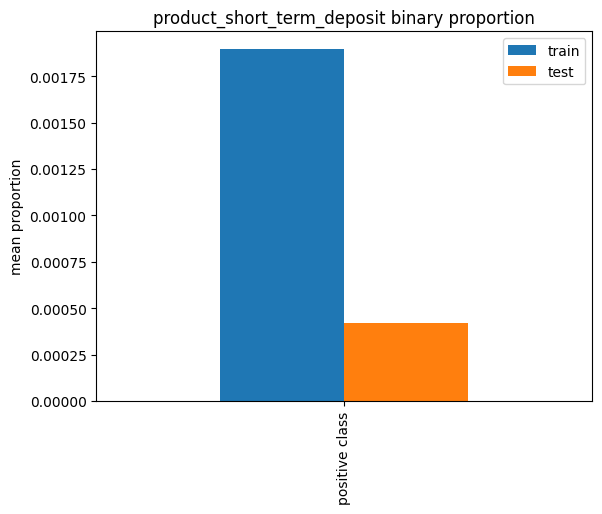

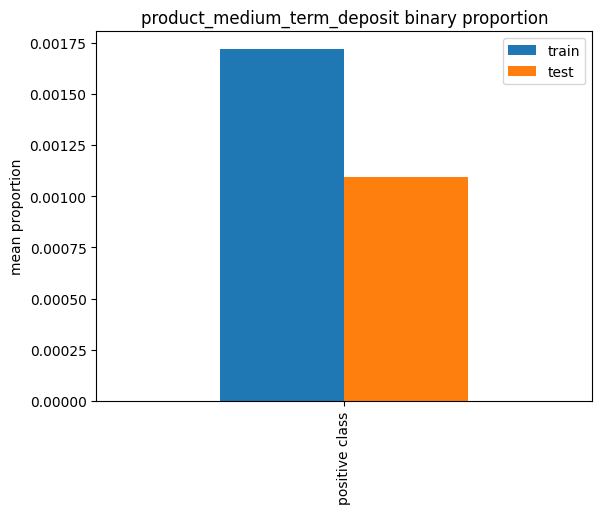

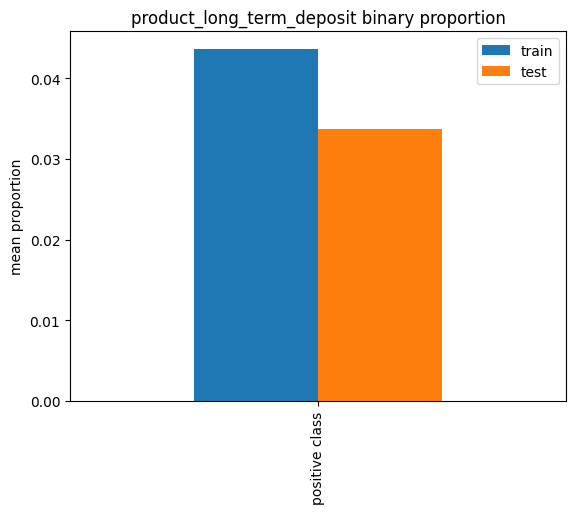

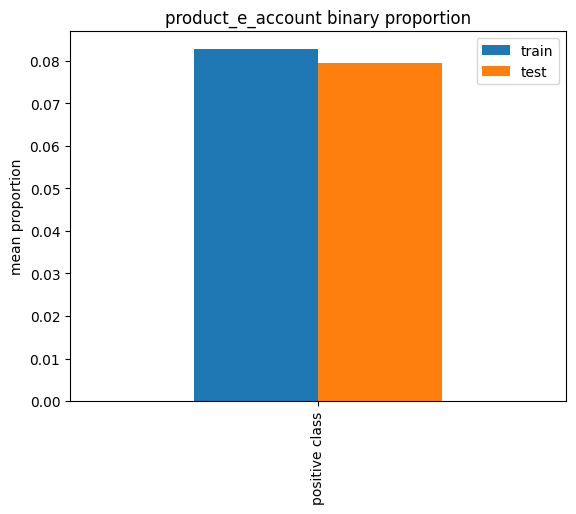

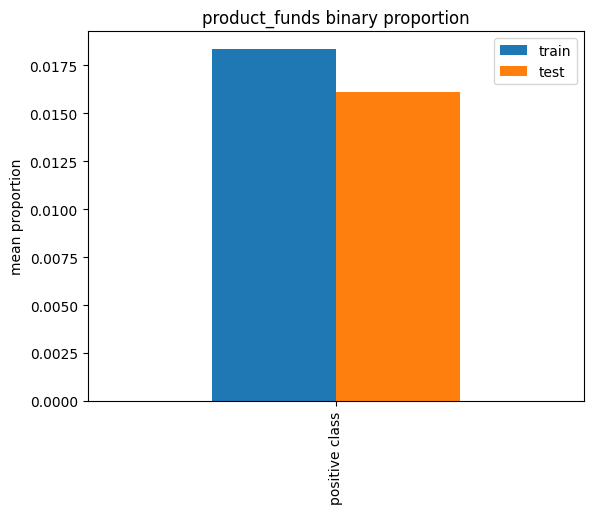

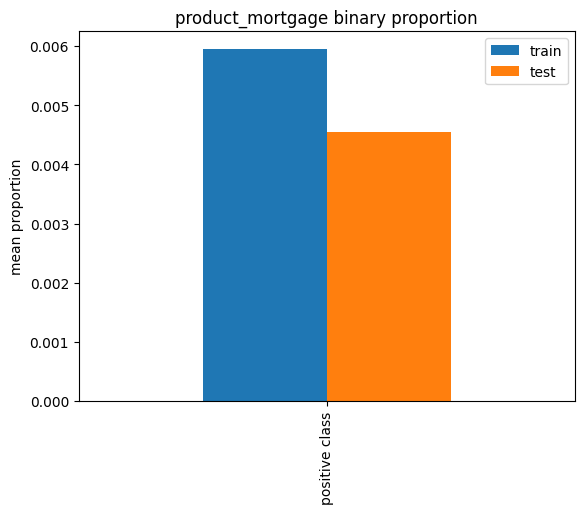

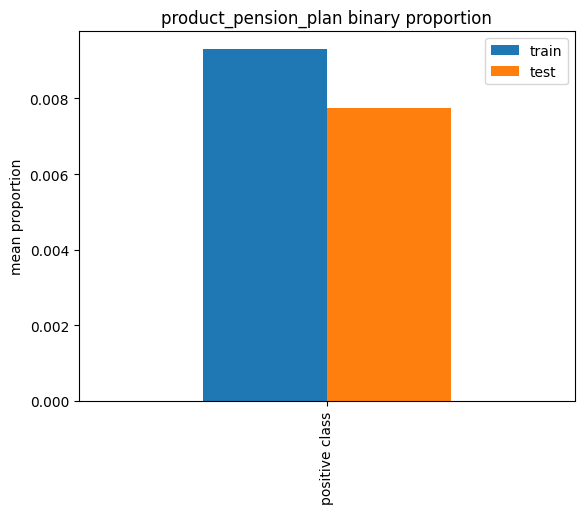

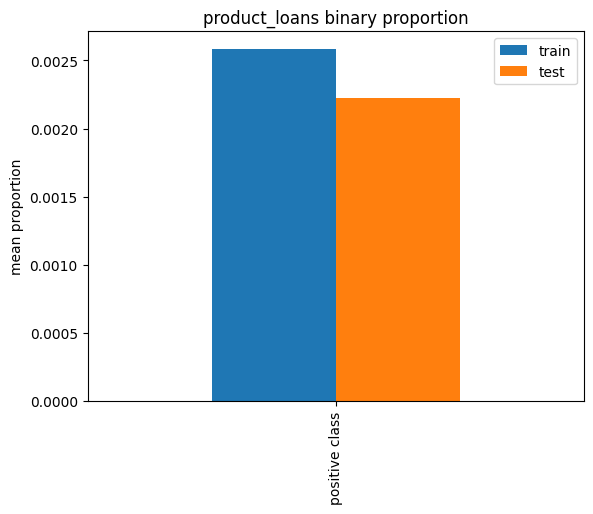

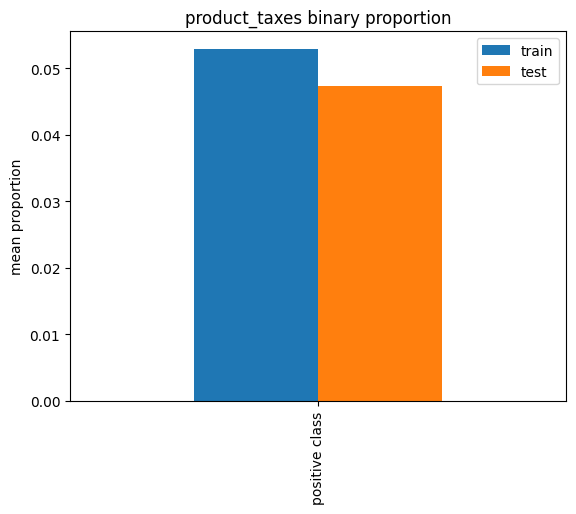

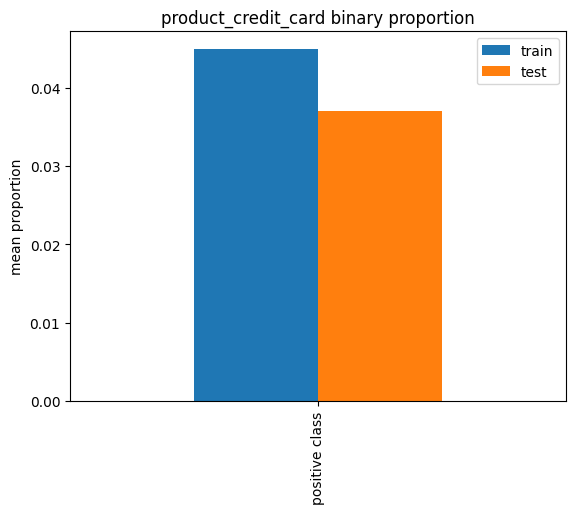

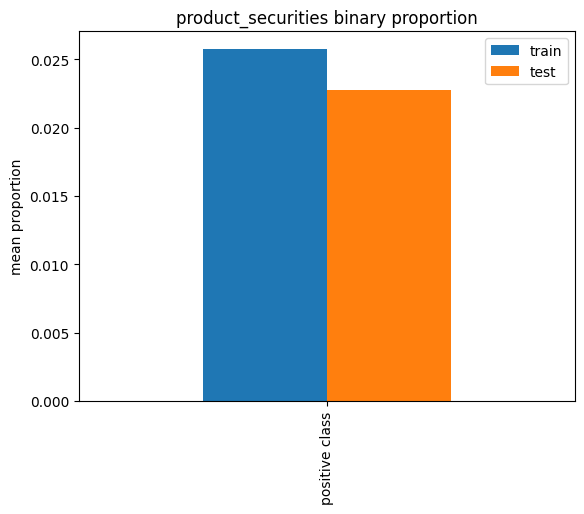

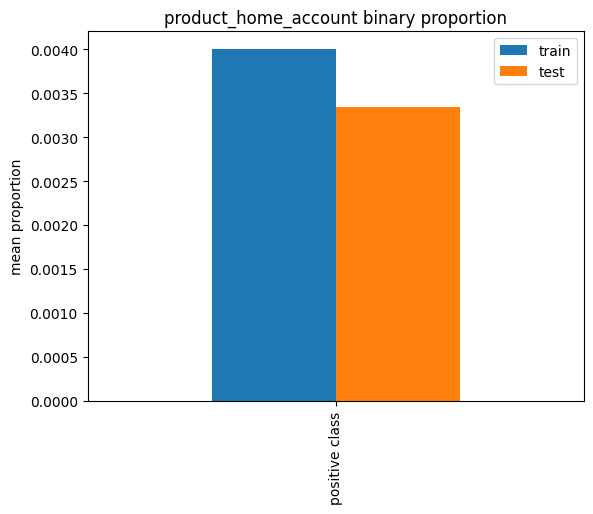

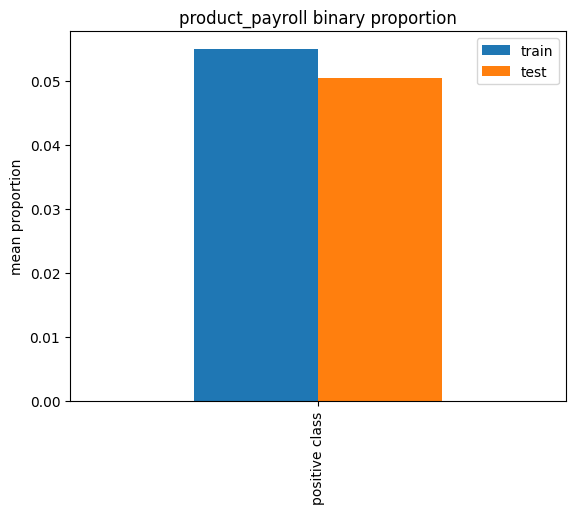

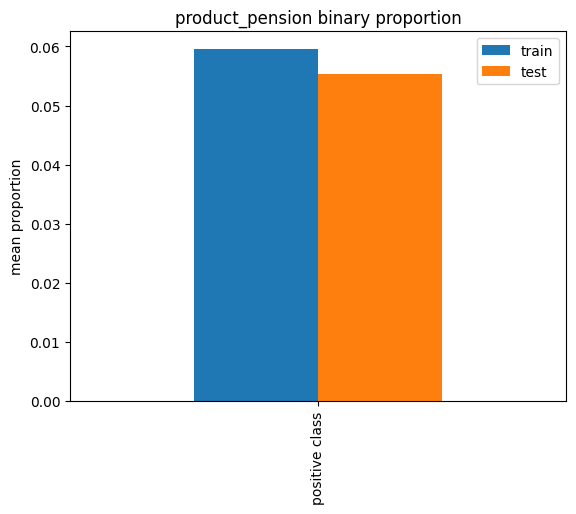

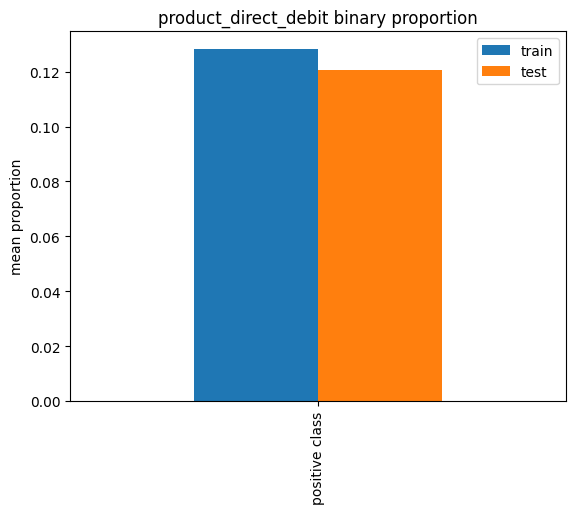

In [62]:
rename_map_test = {
    'product_saving_account': 'product_savings_account',
    'product_Derivada_account': 'product_derivada_account',
    'product_más_particular_account': 'product_mas_particular_account',
    'product_particular+_account': 'product_particular_plus_account',
    'product_short_deposit': 'product_short_term_deposit',
    'product_medium_deposit': 'product_medium_term_deposit',
    'product_long_deposit': 'product_long_term_deposit',
    'product_pensions_plan': 'product_pension_plan',
    'product_security': 'product_securities',
    'product_pensions': 'product_pension'
}
df_test.rename(columns=rename_map_test, inplace=True)

for col in binary_cols:

    train_mean = pd.to_numeric(df_clean[col], errors='coerce').mean()
    test_mean  = pd.to_numeric(df_test[col], errors='coerce').mean()

    compare = pd.DataFrame({
        'train': [train_mean],
        'test': [test_mean]
    })

    compare.plot(kind='bar')

    plt.title(f'{col} binary proportion')
    plt.ylabel('mean proportion')

    plt.xticks([0], ['positive class'])

    plt.show()

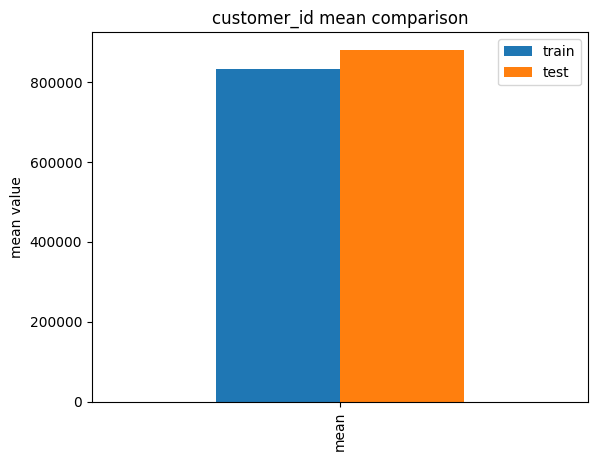

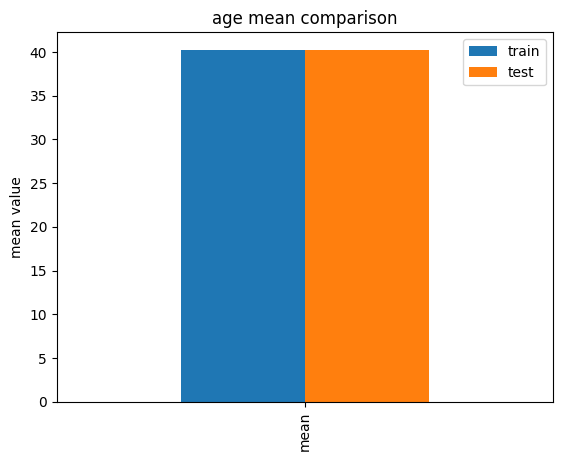

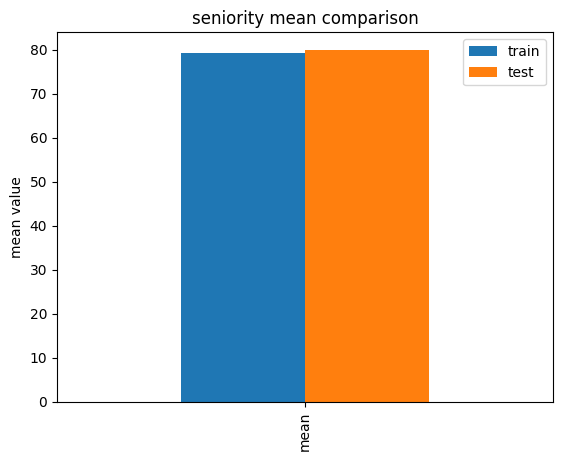

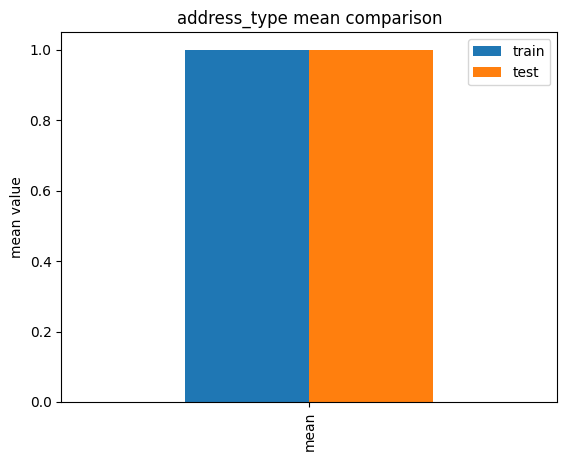

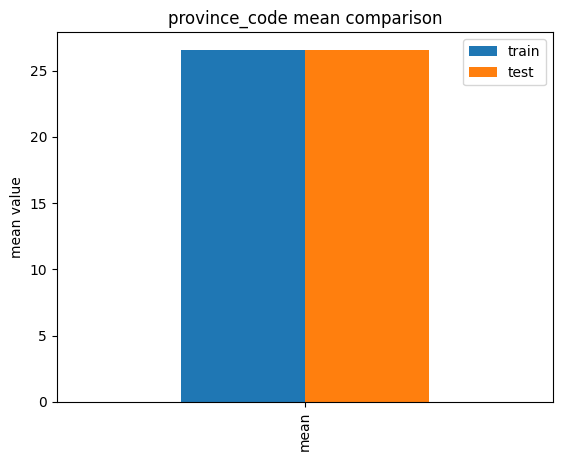

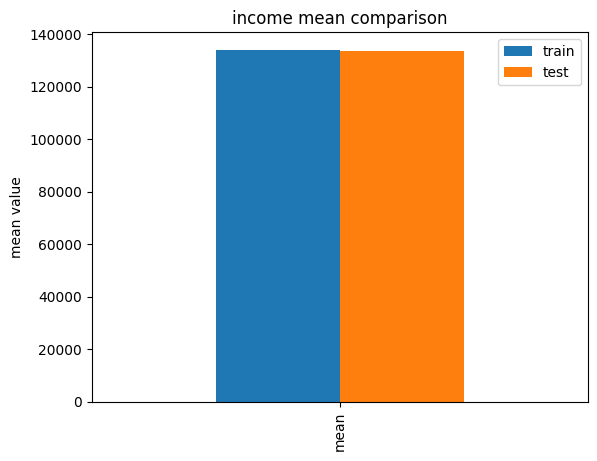

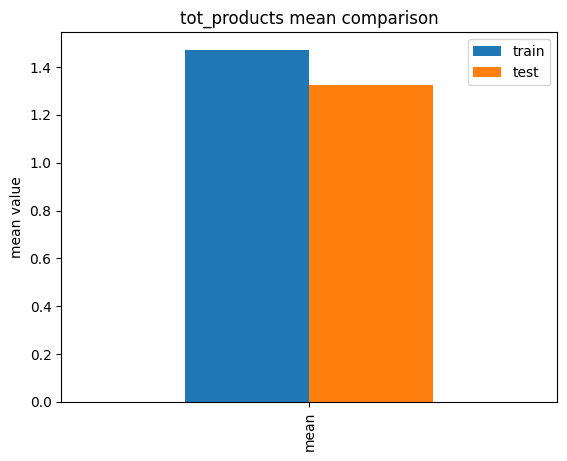

In [64]:
df_test['tot_products'] = df_test[product_col_test].sum(axis=1)

for col in numeric_cols:

    train_mean = df_clean[col].mean()
    test_mean = df_test[col].mean()

    compare = pd.DataFrame({
        'train': [train_mean],
        'test': [test_mean]
    })

    compare.plot(kind='bar')

    plt.title(f'{col} mean comparison')
    plt.ylabel('mean value')
    plt.xticks([0], ['mean'])

    plt.show()

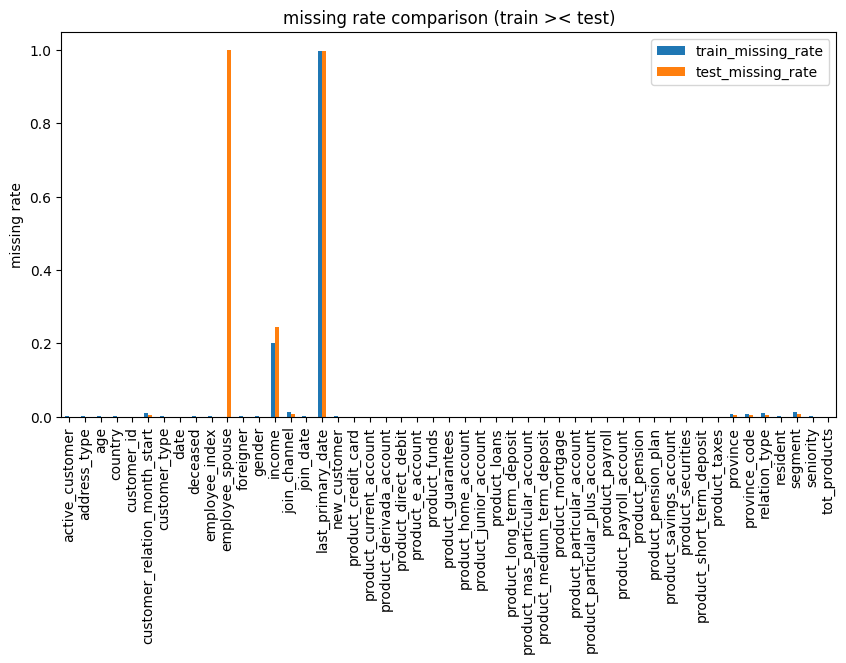

In [65]:
train_missing=df_clean.isnull().mean()
test_missing=df_test.isnull().mean()
missing_compare=pd.DataFrame({
    'train_missing_rate': train_missing,
    'test_missing_rate': test_missing
})
missing_compare.plot(kind='bar', figsize=(10, 5))
plt.title('missing rate comparison (train >< test)')
plt.ylabel('missing rate')
plt.xticks(rotation=90)
plt.show()

Column last_primary_date, and employee_spouse have same missing rate. Missing rate in training file is higher than testing file at column customer_relation_month_start, relation_type, province code, province, and segment. Missing rate in testing file is higher than training file at column income